In [586]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 26})
import matplotlib as mpl
mpl.rcParams['font.family'] = 'monospace' 

from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts import analysis_utils as au
import importlib
importlib.reload(au)

<module 'scripts.analysis_utils' from '/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py'>

In [587]:
data_1 = np.concatenate((np.loadtxt('single_day_2026_04_05_injections.txt'),
                        np.loadtxt('single_day_20260402_results.txt'),
                        np.loadtxt('single_day_2026_04_08_injections.txt'),
                        np.loadtxt('single_day_2026_04_11_injections.txt'),
                        np.loadtxt('single_day_2026_04_14_injections.txt'),
                        np.loadtxt('single_day_2026_04_17_injections.txt'),
                        np.loadtxt('single_day_2026_04_20_injections.txt'),
                        np.loadtxt('single_day_2026_04_23_injections.txt')
                        )
)
print(f'Number of pointings: {len(np.unique(data_1[:, 0:2], axis=0))}')
#print(f'Number of days: {len(np.unique(data_1[:, 2]))}')
print(f'Total fraction of recovered injections: {(100*len(data_1[data_1[:, -1] > 0.])/len(data_1)):.2f}%')
print(f'Number of injections: {len(data_1)}')
RA = data_1[:, 0]
Dec = data_1[:, 1]
f = data_1[:, 4]
DM = data_1[:, 5]
S = data_1[:, 6]
TPA_idx = data_1[:, 3].astype('int')
fwhm = data_1[:, 7]

f_idx = 4 
DM_idx = 5
S_idx = 6
FWHM_idx = 7

Number of pointings: 3036
Total fraction of recovered injections: 28.10%
Number of injections: 47577


In [588]:
fglob_mask_1 = (data_1[:, f_idx] > 0.1) & (data_1[:, f_idx] < 250.)
DMglob_mask_1 = (data_1[:, DM_idx] > 1.) & (data_1[:, DM_idx] < 600.)
Sglob_mask_1 = data_1[:, S_idx] > 0.1
glob_mask_1 = fglob_mask_1 & DMglob_mask_1 & Sglob_mask_1

In [589]:
RA_bins = np.arange(min(RA), max(RA), 0.5)
Dec_bins = np.arange(min(Dec), max(Dec), 0.5)
f_bins = np.logspace(np.log10(min(f)), np.log10(max(f)), 1000)
DM_bins = np.arange(min(DM), 500)
S_bins = np.logspace(np.log10(0.05), np.log10(max(S)), 1000)
fwhm_bins = np.logspace(np.log10(min(fwhm)), np.log10(0.15), 1000)

In [590]:
f_dev = 100
DM_dev = 100
S_dev = 100
FWHM_dev = 80

All data_1:

In [591]:
dm_f_inj_smooth_1, dm_f_ret_p_1, dm_f_ret_p_smooth_1 = au.get_sensitivity(
    data_1[Sglob_mask_1],
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
)

dm_s_inj_smooth_1, dm_s_ret_p_1, dm_s_ret_p_smooth_1 = au.get_sensitivity(
    data_1[fglob_mask_1],
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
)

s_f_inj_smooth_1, s_f_ret_p_1, s_f_ret_p_smooth_1 = au.get_sensitivity(
    data_1[DMglob_mask_1],
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
)

s_fwhm_inj_smooth_1, s_fwhm_ret_p_1, s_fwhm_ret_p_smooth_1 = au.get_sensitivity(
    data_1[fglob_mask_1 & DMglob_mask_1],
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
)

dm_fwhm_inj_smooth_1, dm_fwhm_ret_p_1, dm_fwhm_ret_p_smooth_1 = au.get_sensitivity(
    data_1[fglob_mask_1 & Sglob_mask_1],
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
)

fwhm_f_inj_smooth_1, fwhm_f_ret_p_1, fwhm_f_ret_p_smooth_1 = au.get_sensitivity(
    data_1[DMglob_mask_1 & Sglob_mask_1],
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d'
)

In [592]:
bins1 = [f_bins, f_bins, f_bins, fwhm_bins, fwhm_bins, S_bins]
bins2 = [DM_bins, S_bins, fwhm_bins, S_bins, DM_bins,  DM_bins]

dev1 = [f_dev, f_dev, f_dev, FWHM_dev, FWHM_dev, f_dev]
dev2 = [DM_dev, S_dev, FWHM_dev, S_dev, DM_dev, DM_dev]

In [593]:
importlib.reload(au)

<module 'scripts.analysis_utils' from '/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py'>

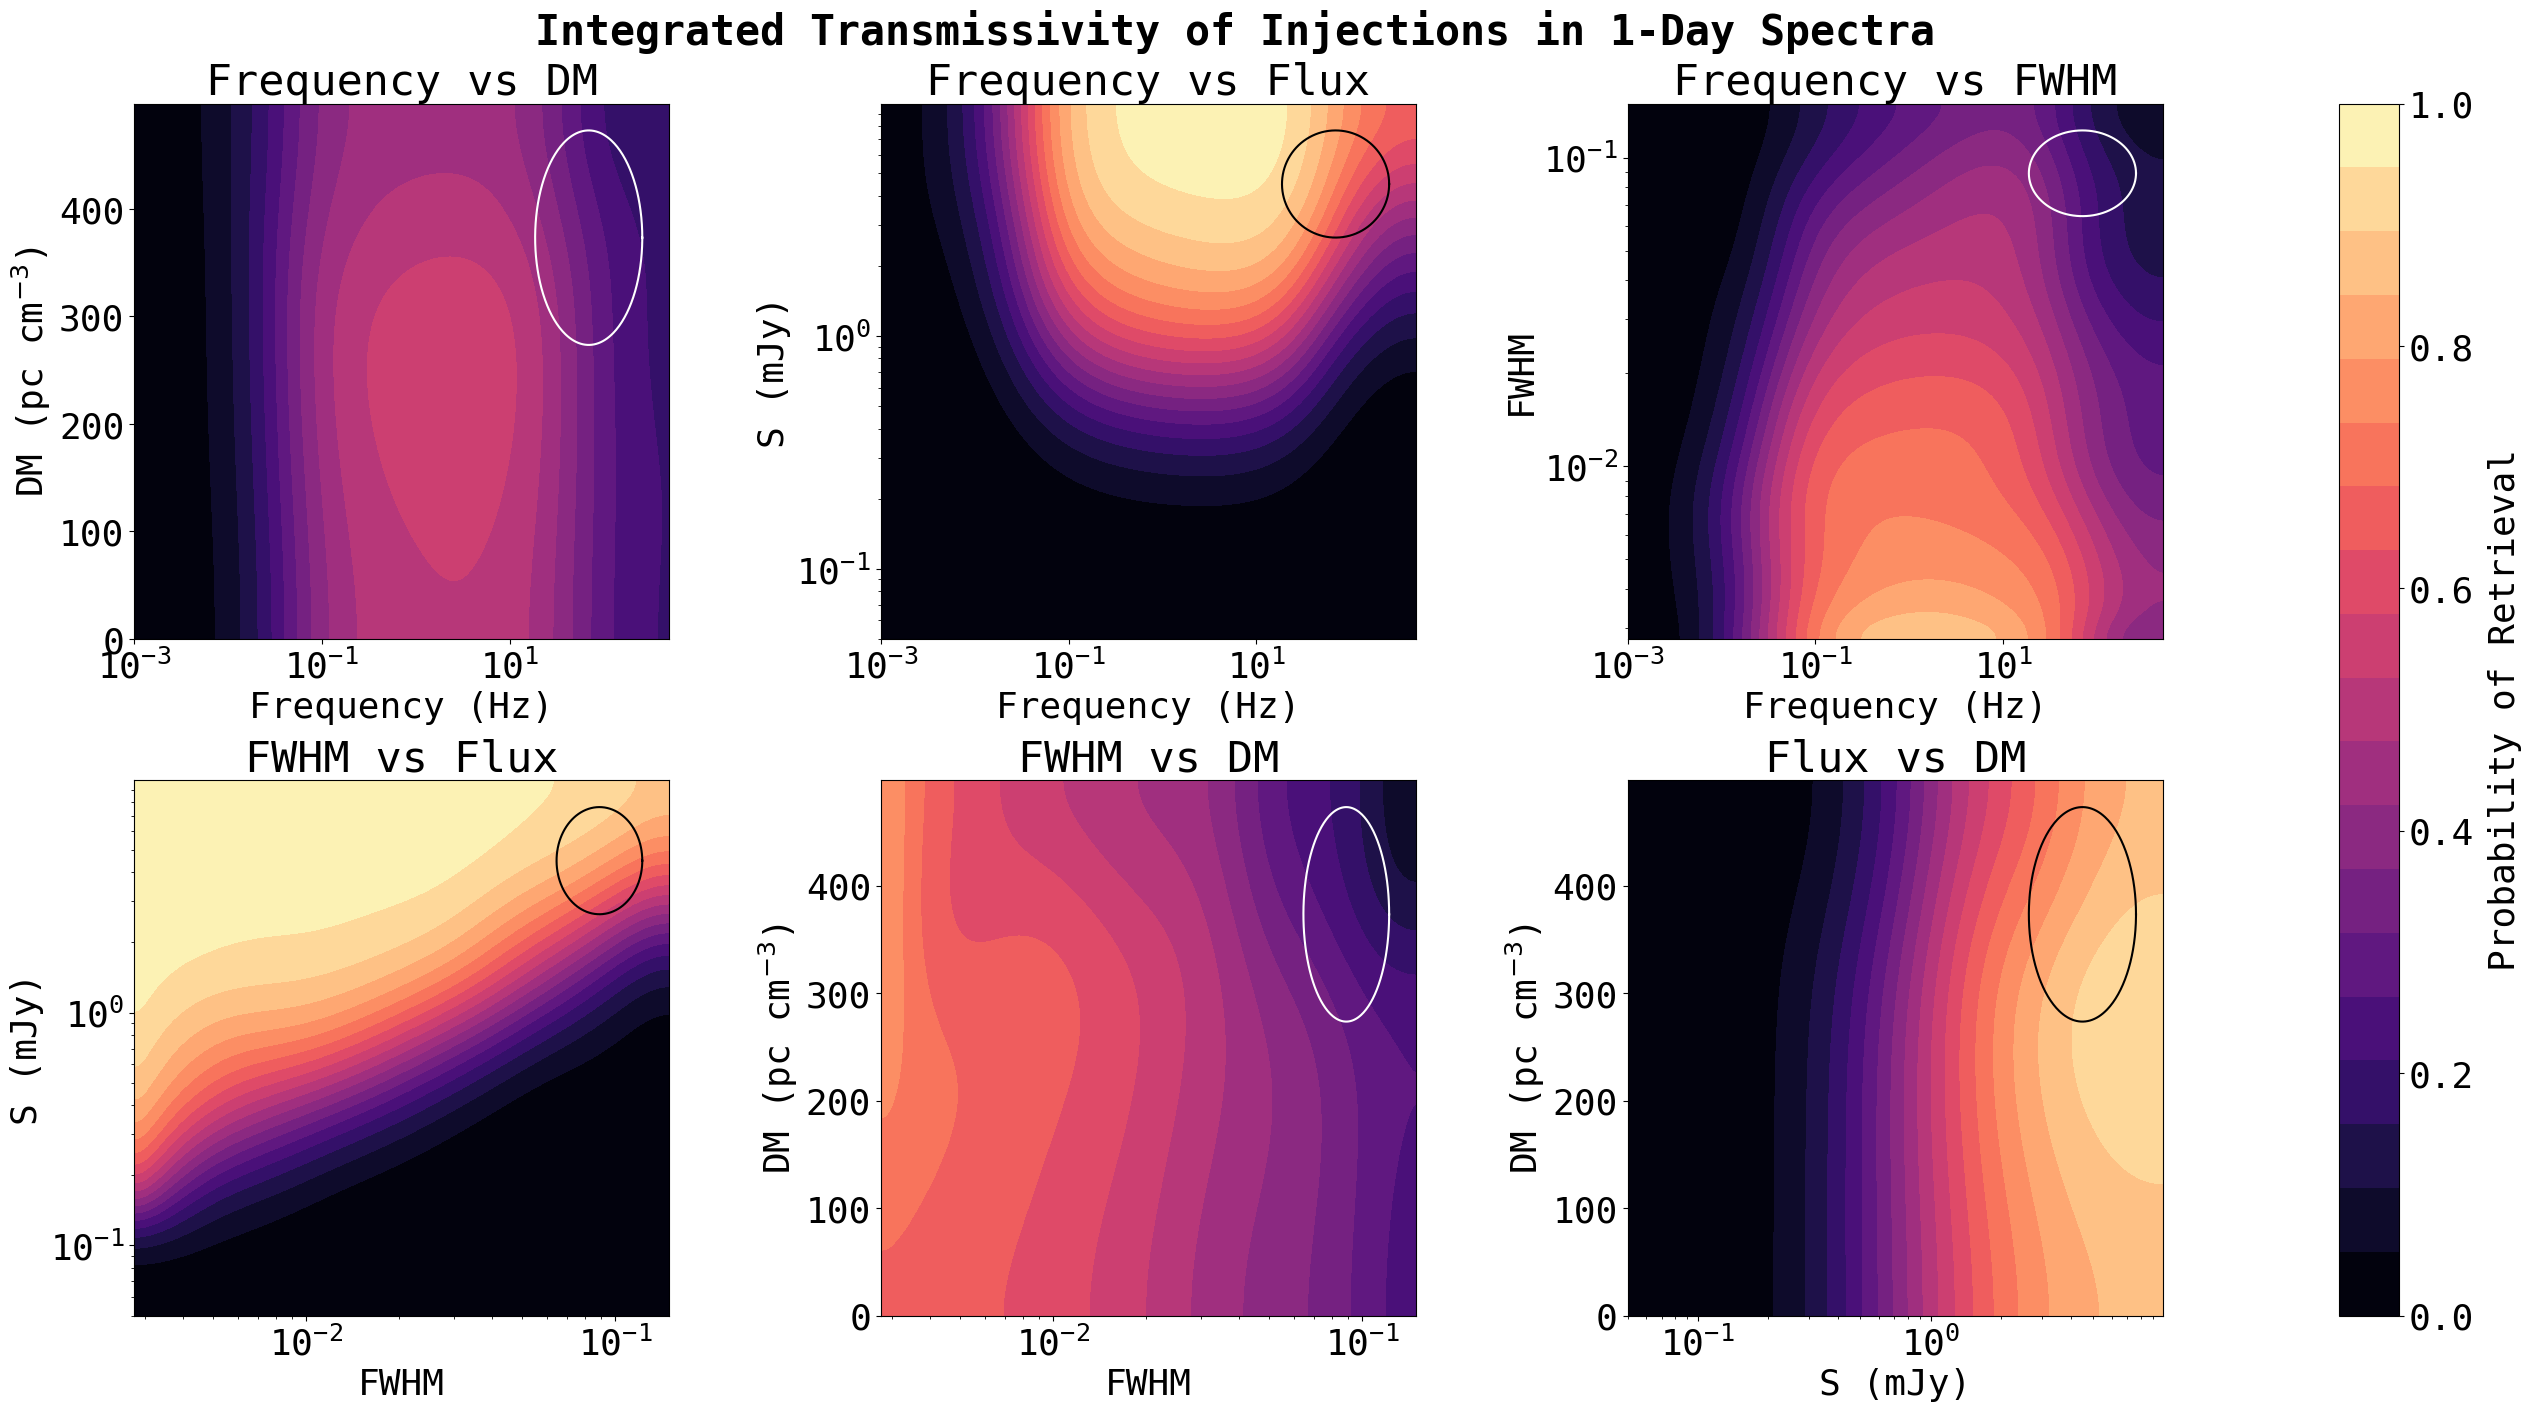

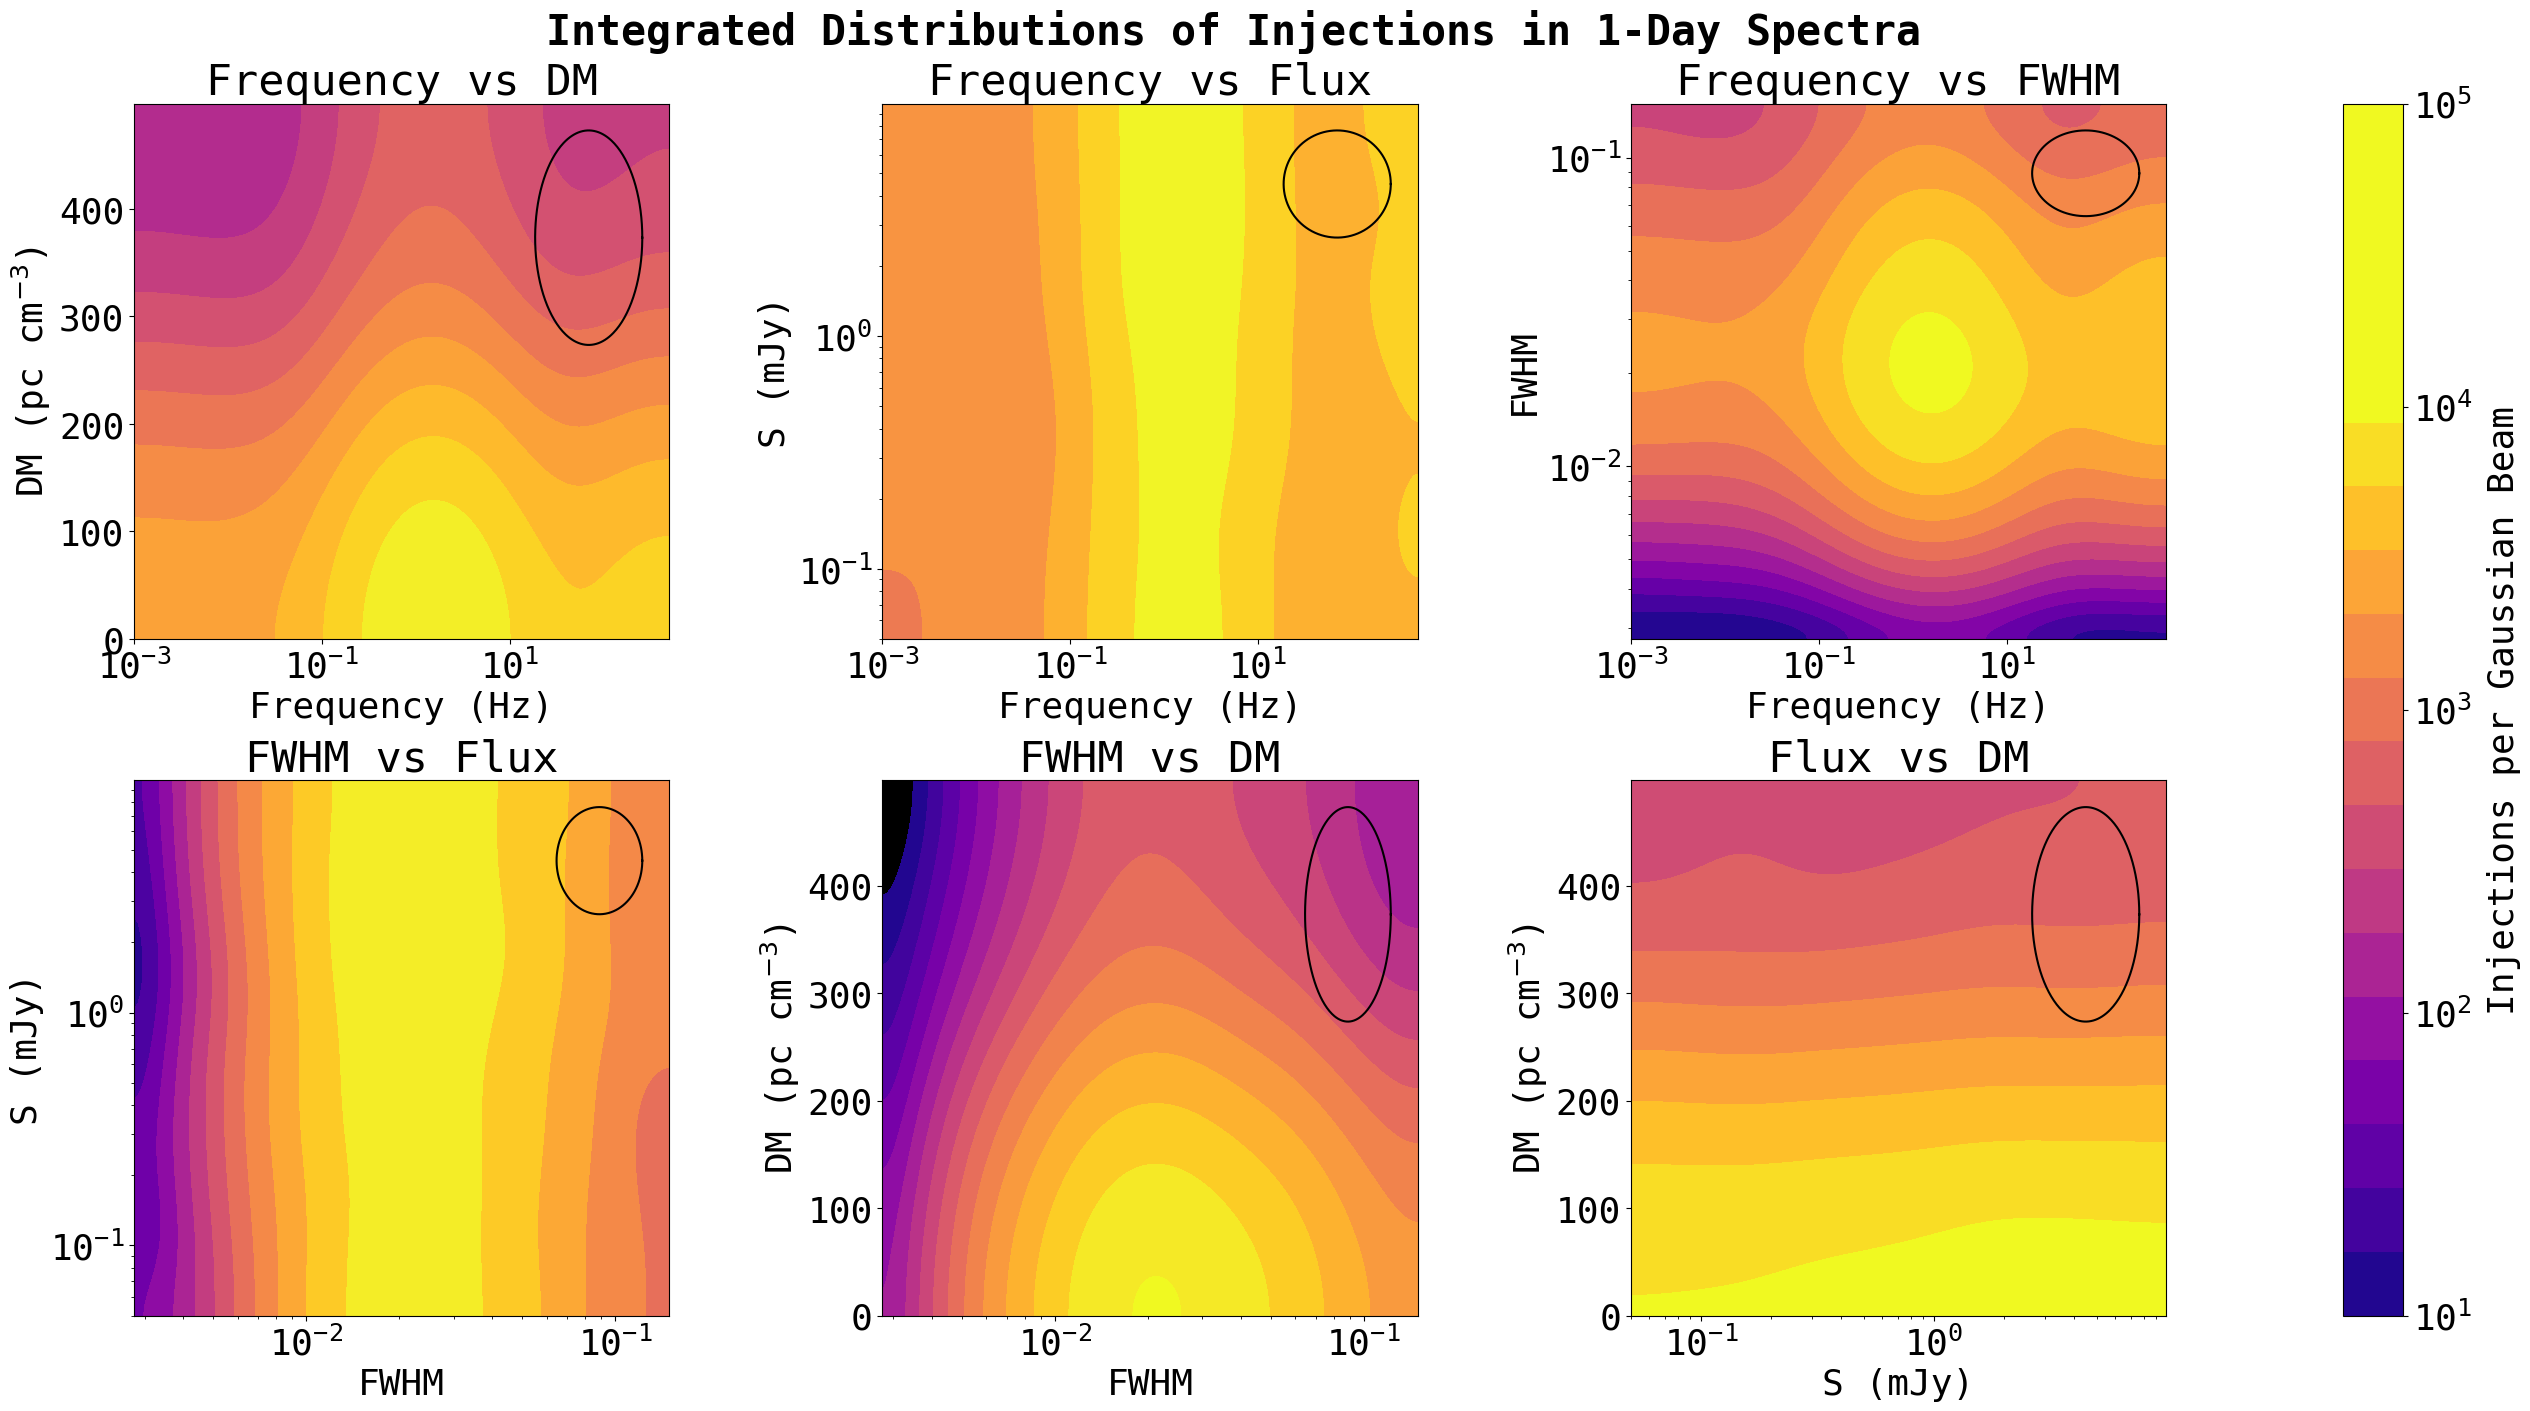

In [594]:
transmissivities_1 = [dm_f_ret_p_smooth_1, s_f_ret_p_smooth_1, fwhm_f_ret_p_smooth_1,
             s_fwhm_ret_p_smooth_1, dm_fwhm_ret_p_smooth_1, dm_s_ret_p_smooth_1]

au.make_contour_map(transmissivities_1,
                     bins1, bins2, 
                     dev1, dev2, 
                     'Integrated Transmissivity of Injections in 1-Day Spectra',
                     ellipse_colors = ['w', 'k', 'w', 'k', 'w', 'k']
                     )

injections_1 = [dm_f_inj_smooth_1,  
                s_f_inj_smooth_1,
                fwhm_f_inj_smooth_1,
                s_fwhm_inj_smooth_1, 
                dm_fwhm_inj_smooth_1,
                dm_s_inj_smooth_1, 
                ]

au.make_contour_map(injections_1,
                     bins1, bins2, 
                     dev1, dev2, 
                     'Integrated Distributions of Injections in 1-Day Spectra',
                     cmap = 'plasma',
                     colorbar_name = 'Injections per Gaussian Beam',
                     cmap_log = True,
                     ellipse_colors = ['k', 'k', 'k', 'k', 'k', 'k']
                     )

In [595]:
S_mask = data_1[:, 6] < 0.1
retrieved_mask = data_1[:, -1] > 0
data_1_low_flux = data_1[S_mask]
data_1_low_flux_retrieved = data_1[S_mask & retrieved_mask]
100*len(data_1_low_flux_retrieved) / len(data_1_low_flux)

0.03405066739308091

In [596]:
sigma_mask = data_1[:, 8] > 6.

dm_f_inj_smooth_1, _, dm_f_ret_p_smooth_1 = au.get_sensitivity(
    data_1[sigma_mask & Sglob_mask_1],
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
)

dm_s_inj_smooth_1, _, dm_s_ret_p_smooth_1 = au.get_sensitivity(
    data_1[sigma_mask & fglob_mask_1],
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
)

s_f_inj_smooth_1, _, s_f_ret_p_smooth_1 = au.get_sensitivity(
    data_1[sigma_mask & DMglob_mask_1],
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
)

s_fwhm_inj_smooth_1, _, s_fwhm_ret_p_smooth_1 = au.get_sensitivity(
    data_1[sigma_mask & fglob_mask_1 & DMglob_mask_1],
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
)

dm_fwhm_inj_smooth_1, _, dm_fwhm_ret_p_smooth_1 = au.get_sensitivity(
    data_1[sigma_mask & fglob_mask_1 & Sglob_mask_1],
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
)

fwhm_f_inj_smooth_1, _, fwhm_f_ret_p_smooth_1 = au.get_sensitivity(
    data_1[sigma_mask & DMglob_mask_1 & Sglob_mask_1],
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d'
)

In [597]:
importlib.reload(au)

<module 'scripts.analysis_utils' from '/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py'>

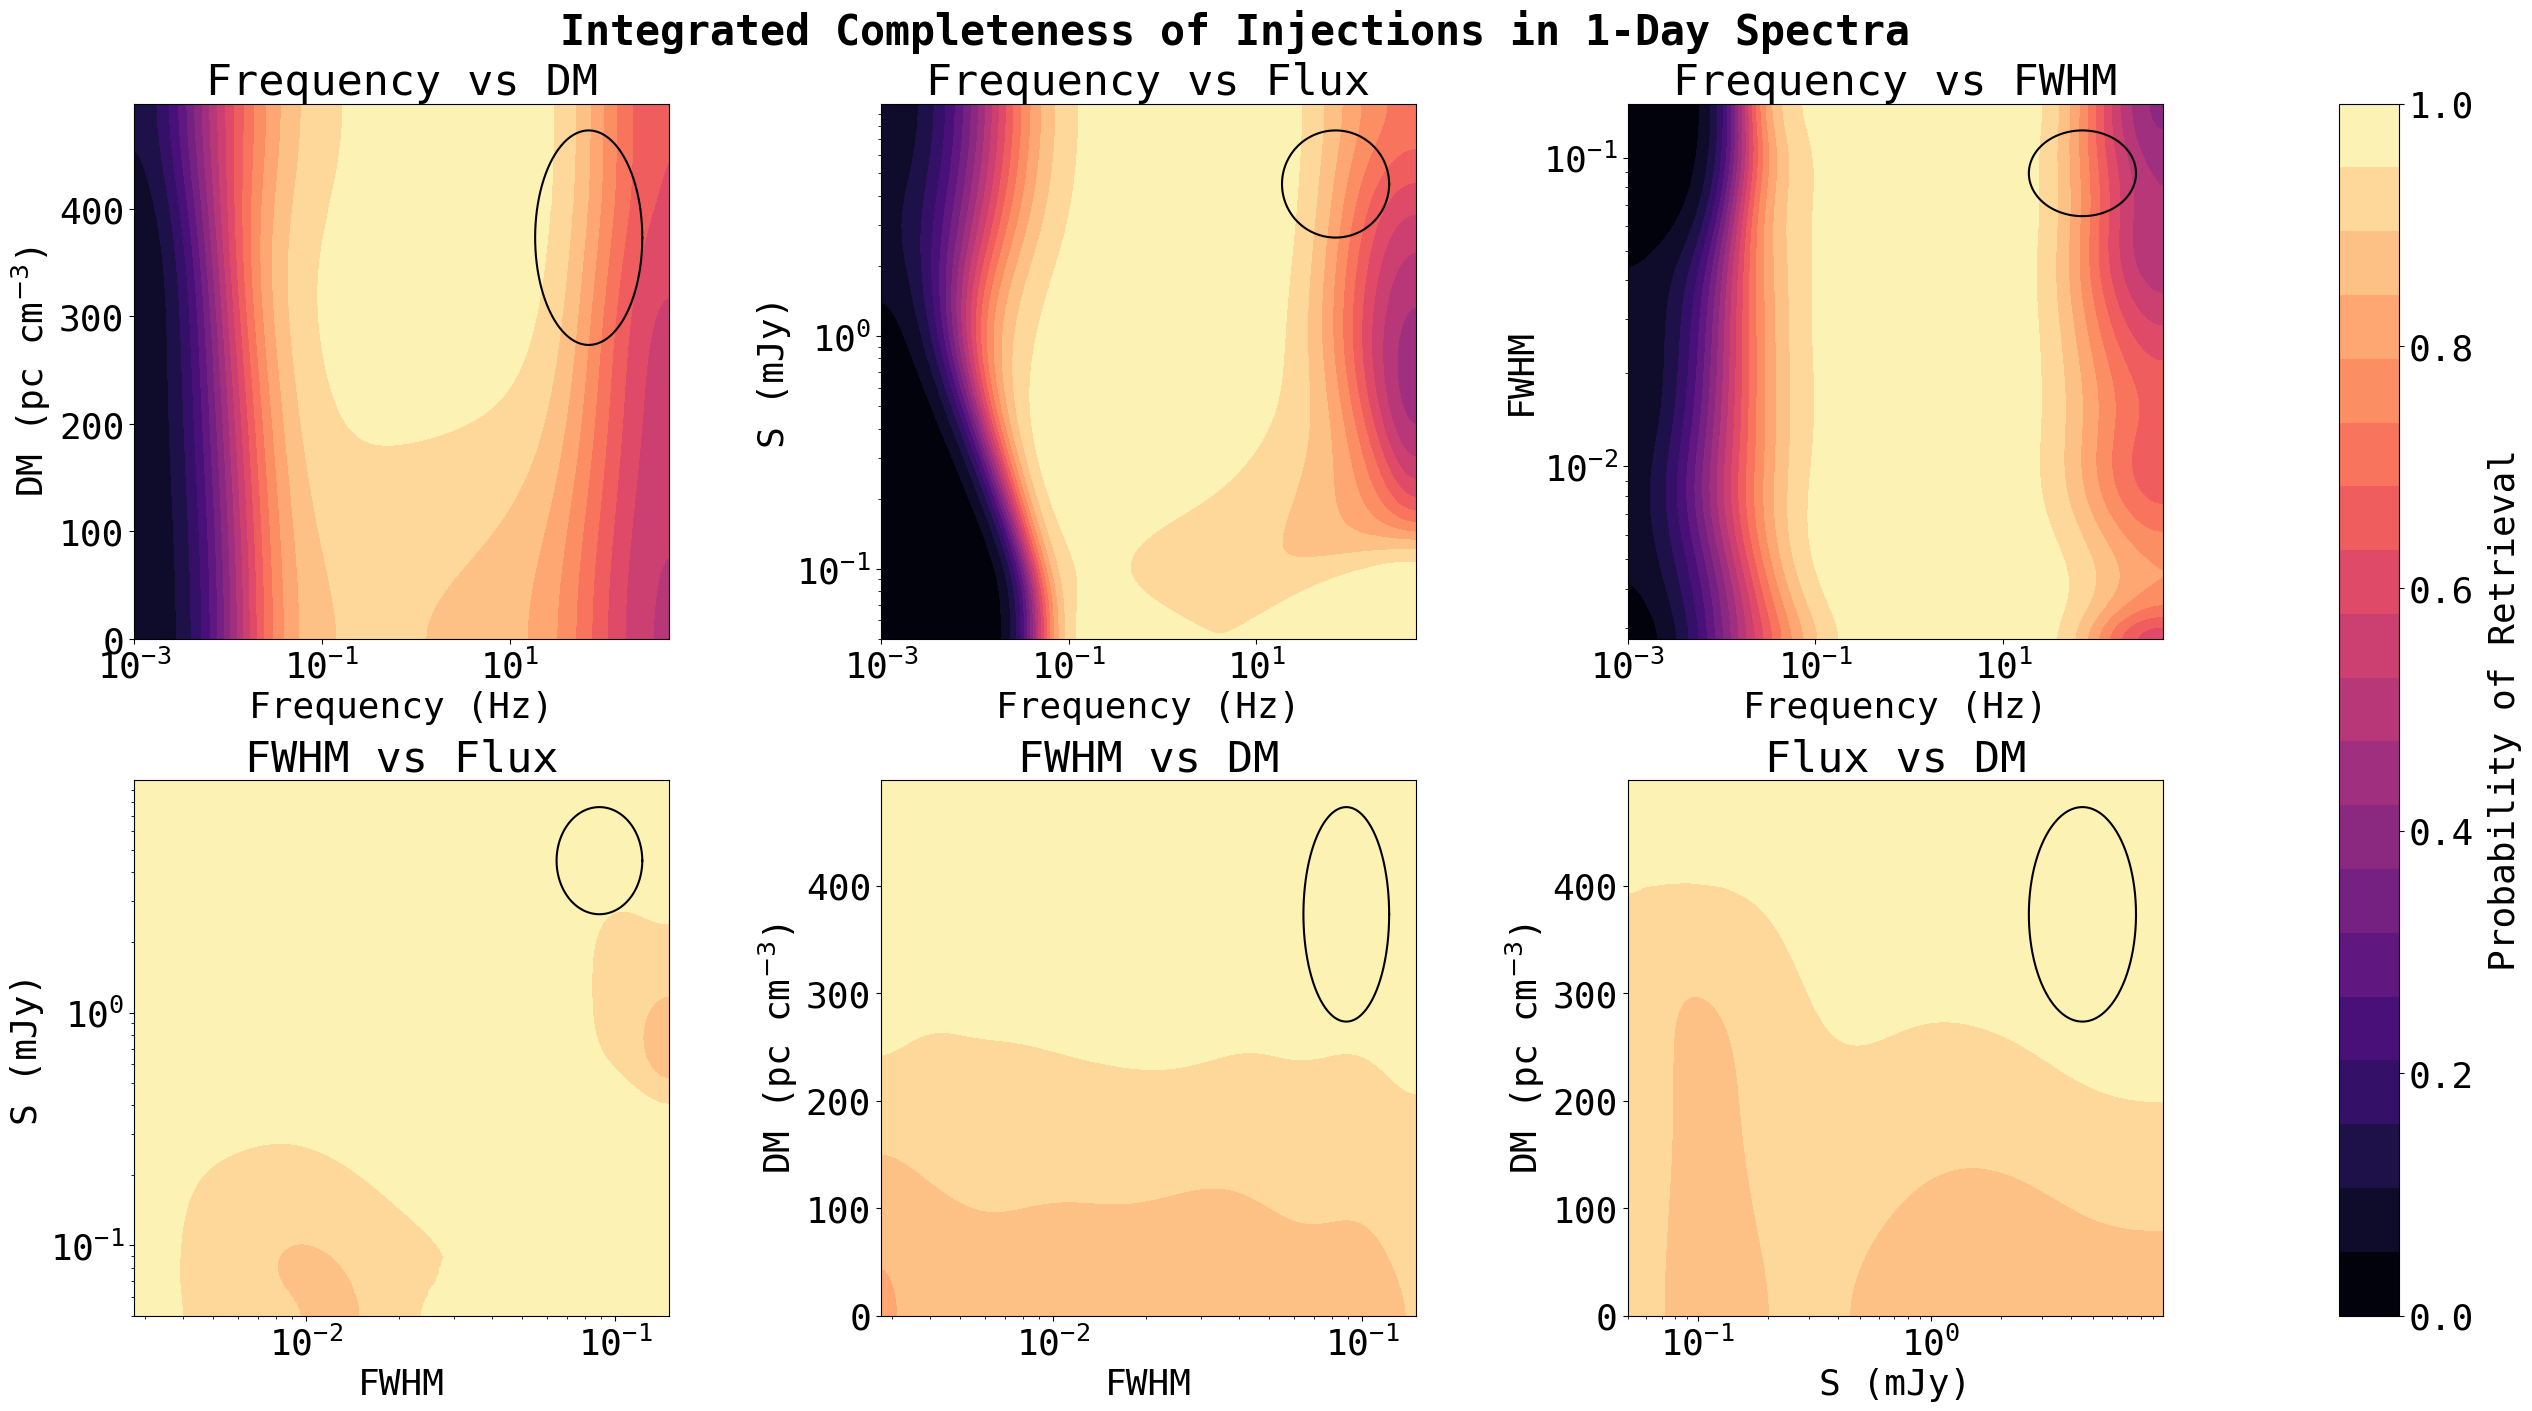

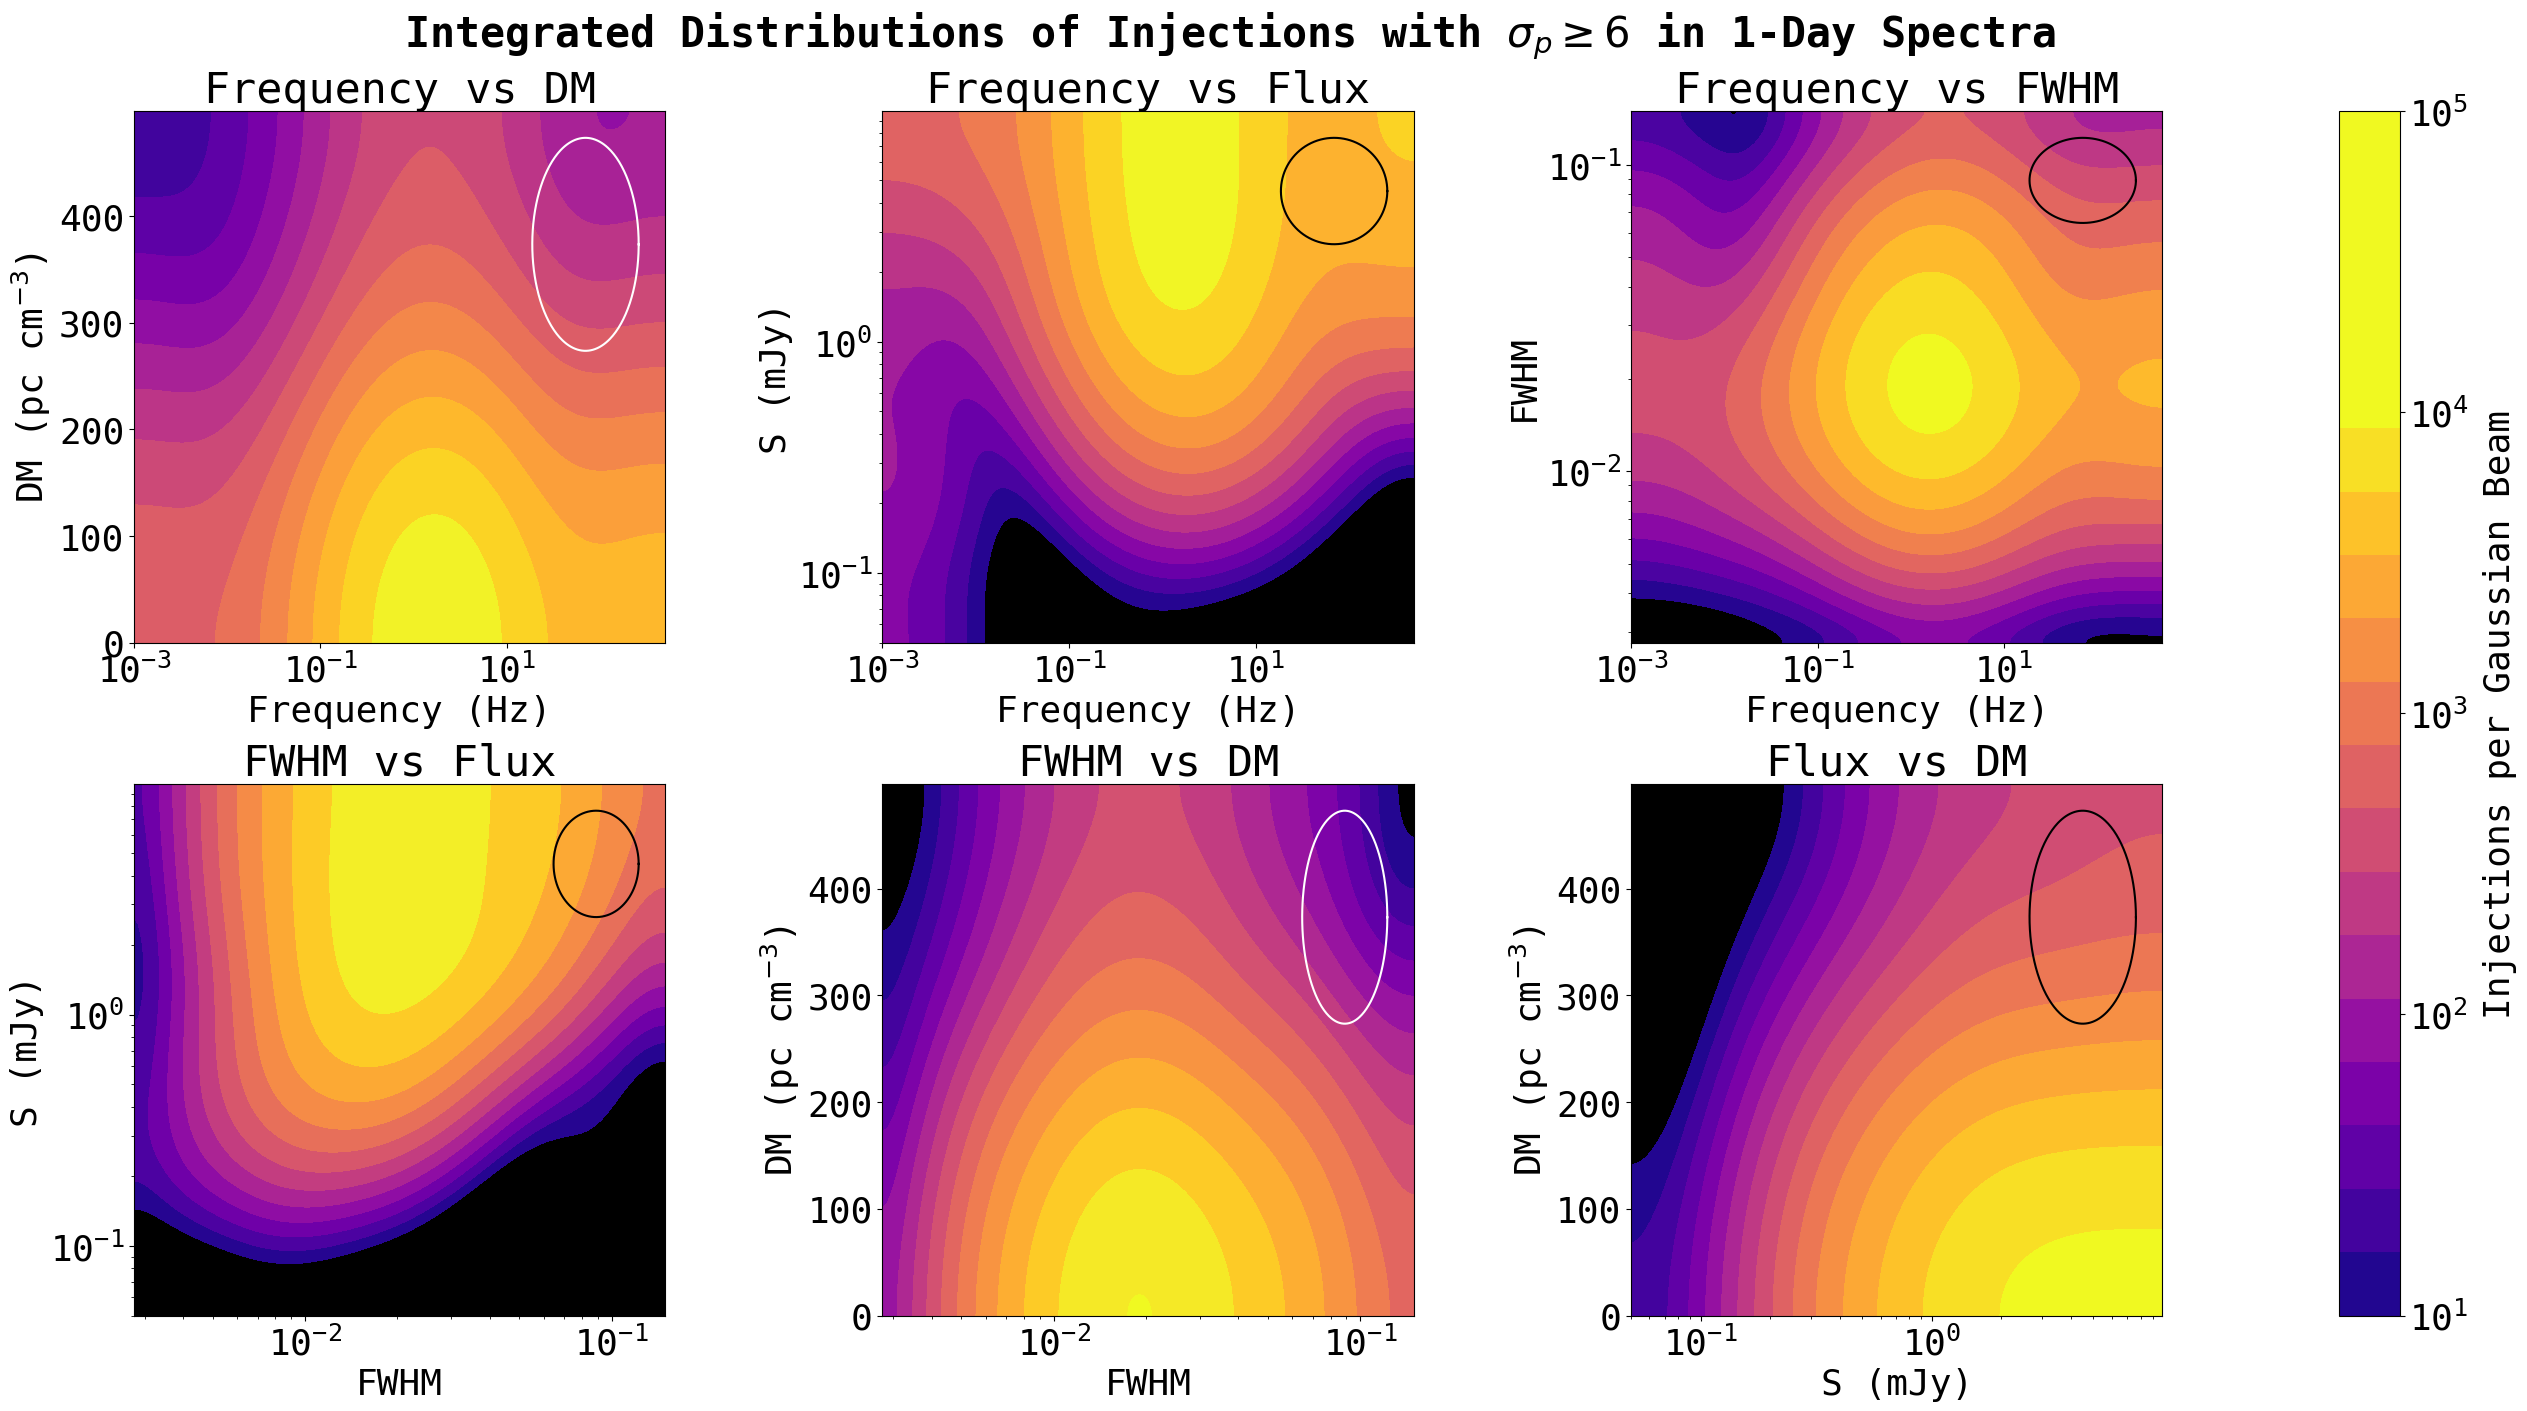

In [598]:
completenesses_1 = [dm_f_ret_p_smooth_1, s_f_ret_p_smooth_1, fwhm_f_ret_p_smooth_1,
             s_fwhm_ret_p_smooth_1, dm_fwhm_ret_p_smooth_1, dm_s_ret_p_smooth_1]

au.make_contour_map(completenesses_1,
                     bins1, bins2, 
                     dev1, dev2, 
                     'Integrated Completeness of Injections in 1-Day Spectra',
                     ellipse_colors = ['k', 'k', 'k', 'k', 'k', 'k']
                     )

injections_1 = [dm_f_inj_smooth_1, 
                s_f_inj_smooth_1,
                fwhm_f_inj_smooth_1,
                s_fwhm_inj_smooth_1, 
                dm_fwhm_inj_smooth_1, 
                dm_s_inj_smooth_1
                ]

au.make_contour_map(injections_1,
                     bins1, bins2, 
                     dev1, dev2, 
                     r'Integrated Distributions of Injections with $\sigma_p \geq 6$ in 1-Day Spectra',
                    cmap = 'plasma',
                     colorbar_name = 'Injections per Gaussian Beam',
                     cmap_log = True,
                     ellipse_colors = ['w', 'k', 'k', 'k', 'w', 'k']
                     )

Same thing but the missed injections difference map:

In [599]:
sigma_mask = (data_1[:, 8] > 6.) 

_, _, dm_f_ret_all = au.get_sensitivity(
    data_1[sigma_mask & Sglob_mask_1],
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
)
_, _, dm_f_ret_first = au.get_sensitivity(
    data_1[sigma_mask & Sglob_mask_1],
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
    def_retrieval = 1,
)
dm_f_weird_harm = dm_f_ret_all - dm_f_ret_first

_, _, dm_s_ret_all = au.get_sensitivity(
    data_1[sigma_mask & fglob_mask_1],
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
)
_, _, dm_s_ret_first = au.get_sensitivity(
    data_1[sigma_mask & fglob_mask_1],
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
    def_retrieval = 1,
)
dm_s_weird_harm = dm_s_ret_all - dm_s_ret_first

_, _, s_f_ret_all = au.get_sensitivity(
    data_1[sigma_mask & DMglob_mask_1],
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
)
_, _, s_f_ret_first = au.get_sensitivity(
    data_1[sigma_mask & DMglob_mask_1],
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
    def_retrieval = 1,
)
s_f_weird_harm = s_f_ret_all - s_f_ret_first

_, _, s_fwhm_ret_all = au.get_sensitivity(
    data_1[sigma_mask & fglob_mask_1 & DMglob_mask_1],
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
)
_, _, s_fwhm_ret_first = au.get_sensitivity(
    data_1[sigma_mask & fglob_mask_1 & DMglob_mask_1],
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
    def_retrieval = 1,
)
s_fwhm_weird_harm = s_fwhm_ret_all - s_fwhm_ret_first

_, _, dm_fwhm_ret_all = au.get_sensitivity(
    data_1[sigma_mask & fglob_mask_1 & Sglob_mask_1],
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
)
_, _, dm_fwhm_ret_first = au.get_sensitivity(
    data_1[sigma_mask & fglob_mask_1 & Sglob_mask_1],
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
    def_retrieval = 1,
)
dm_fwhm_weird_harm = dm_fwhm_ret_all - dm_fwhm_ret_first

_, _, fwhm_f_ret_all = au.get_sensitivity(
    data_1[sigma_mask & DMglob_mask_1 & Sglob_mask_1],
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d'
)
_, _, fwhm_f_ret_first = au.get_sensitivity(
    data_1[sigma_mask & DMglob_mask_1 & Sglob_mask_1],
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d',
    def_retrieval = 1,
)
fwhm_f_weird_harm = fwhm_f_ret_all - fwhm_f_ret_first

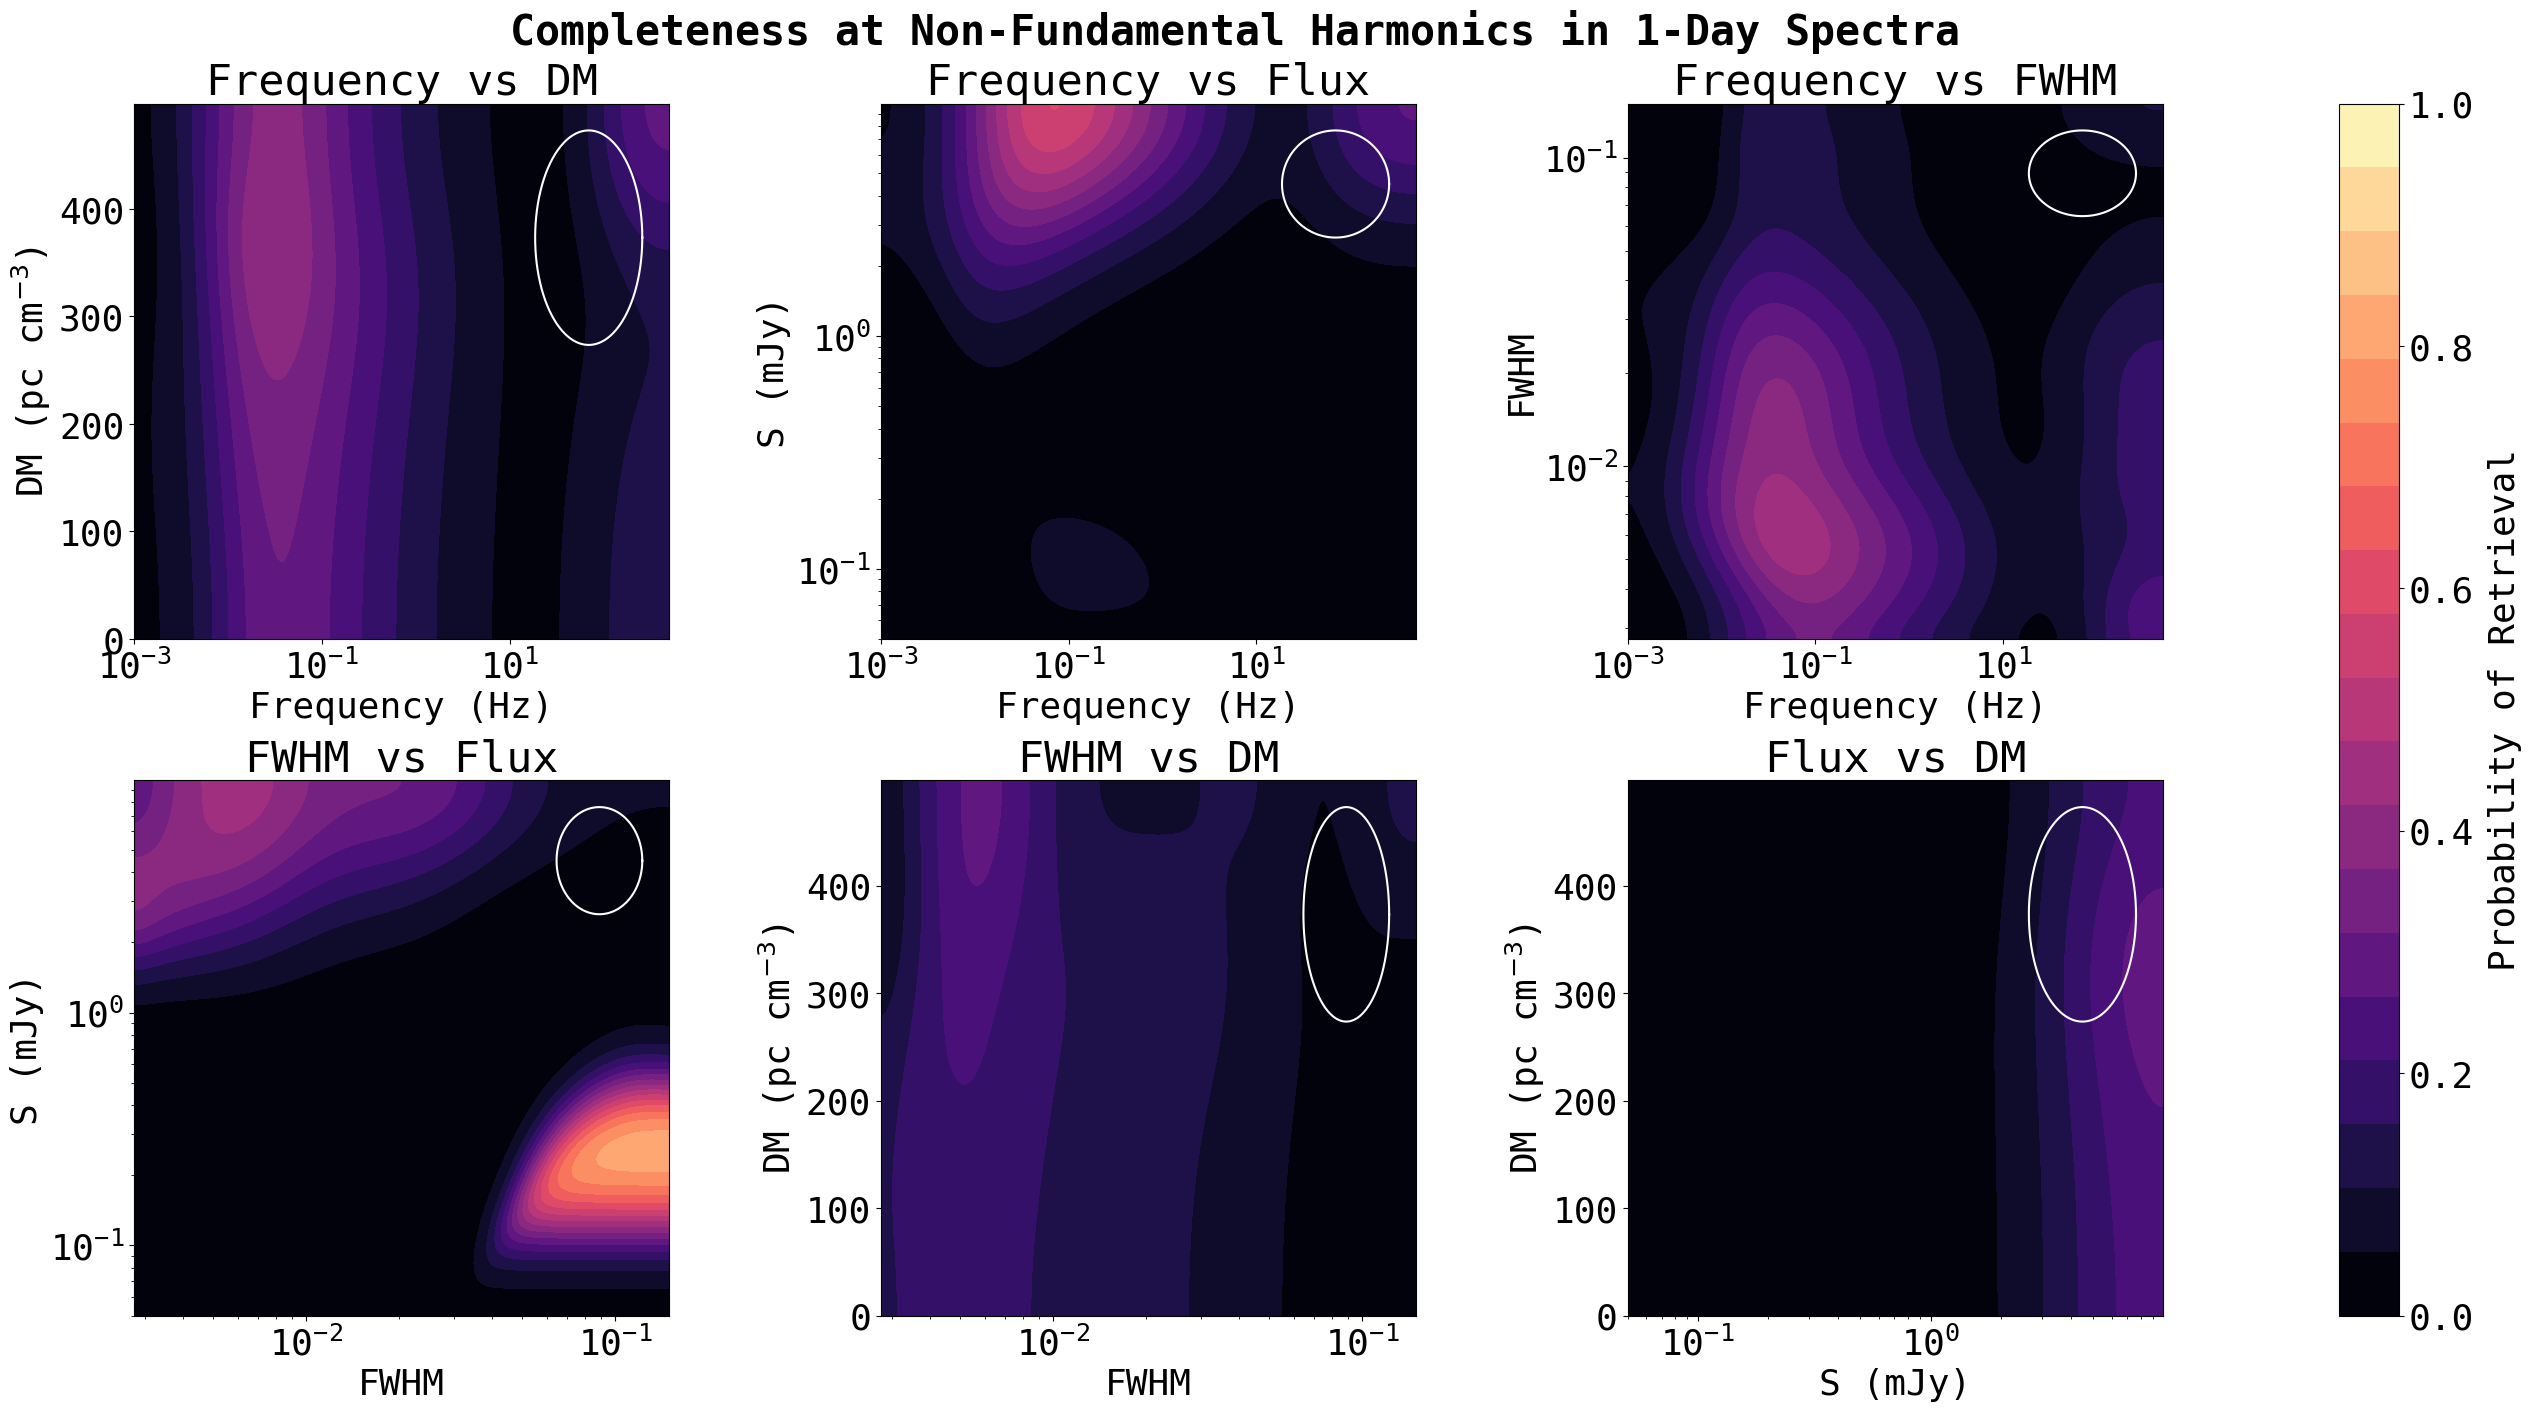

In [600]:
weird_harms_1 = [dm_f_weird_harm, s_f_weird_harm, fwhm_f_weird_harm,
             s_fwhm_weird_harm, dm_fwhm_weird_harm, dm_s_weird_harm]

au.make_contour_map(weird_harms_1,
                     bins1, bins2, 
                     dev1, dev2, 
                     'Completeness at Non-Fundamental Harmonics in 1-Day Spectra',
                     )


Now stacks...

In [601]:
data_stack = np.concatenate((
                        np.unique(np.loadtxt('29_day_injections.txt'), axis = 0),
                        np.unique(np.loadtxt('30_day_injections.txt'), axis = 0)
                        )
                        )
DM_mask = (np.abs(data_stack[:, 5] - data_stack[:, -1]) <= 1.) | (data_stack[:, -1] < 0)
data_stack = data_stack[DM_mask]
print(f'Number of pointings#: {len(np.unique(data_stack[:, 0:2], axis=0))}')
print(f'Total fraction of recovered injections: {(100*len(data_stack[data_stack[:, -1] > 0.])/len(data_stack)):.2f}%')
print(f'Number of injections: {len(data_stack)}')
RA = data_stack[:, 0]
Dec = data_stack[:, 1]
f = data_stack[:, 4]
DM = data_stack[:, 5]
S = data_stack[:, 6]
fwhm = data_stack[:, 7]

Number of pointings#: 2473
Total fraction of recovered injections: 37.64%
Number of injections: 21722


In [602]:
fglob_mask_stack = (data_stack[:, f_idx] > 0.1) & (data_stack[:, f_idx] < 250.)
DMglob_mask_stack = (data_stack[:, DM_idx] > 1.) & (data_stack[:, DM_idx] < 600.)
Sglob_mask_stack = data_stack[:, S_idx] > 0.1
glob_mask_stack = fglob_mask_stack & DMglob_mask_stack & Sglob_mask_stack

In [603]:
dm_f_inj_smooth_30, dm_f_ret_p_30, dm_f_ret_p_smooth_30 = au.get_sensitivity(
    data_stack[Sglob_mask_stack],
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
)

dm_s_inj_smooth_30, dm_s_ret_p_30, dm_s_ret_p_smooth_30 = au.get_sensitivity(
    data_stack[fglob_mask_stack],
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
)

s_f_inj_smooth_30, s_f_ret_p_30, s_f_ret_p_smooth_30 = au.get_sensitivity(
    data_stack[DMglob_mask_stack],
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
)

s_fwhm_inj_smooth_30, s_fwhm_ret_p_30, s_fwhm_ret_p_smooth_30 = au.get_sensitivity(
    data_stack[fglob_mask_stack & DMglob_mask_stack],
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
)

dm_fwhm_inj_smooth_30, dm_fwhm_ret_p_30, dm_fwhm_ret_p_smooth_30 = au.get_sensitivity(
    data_stack[fglob_mask_stack & Sglob_mask_stack],
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
)

fwhm_f_inj_smooth_30, fwhm_f_ret_p_30, fwhm_f_ret_p_smooth_30 = au.get_sensitivity(
    data_stack[DMglob_mask_stack & Sglob_mask_stack],
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d'
)

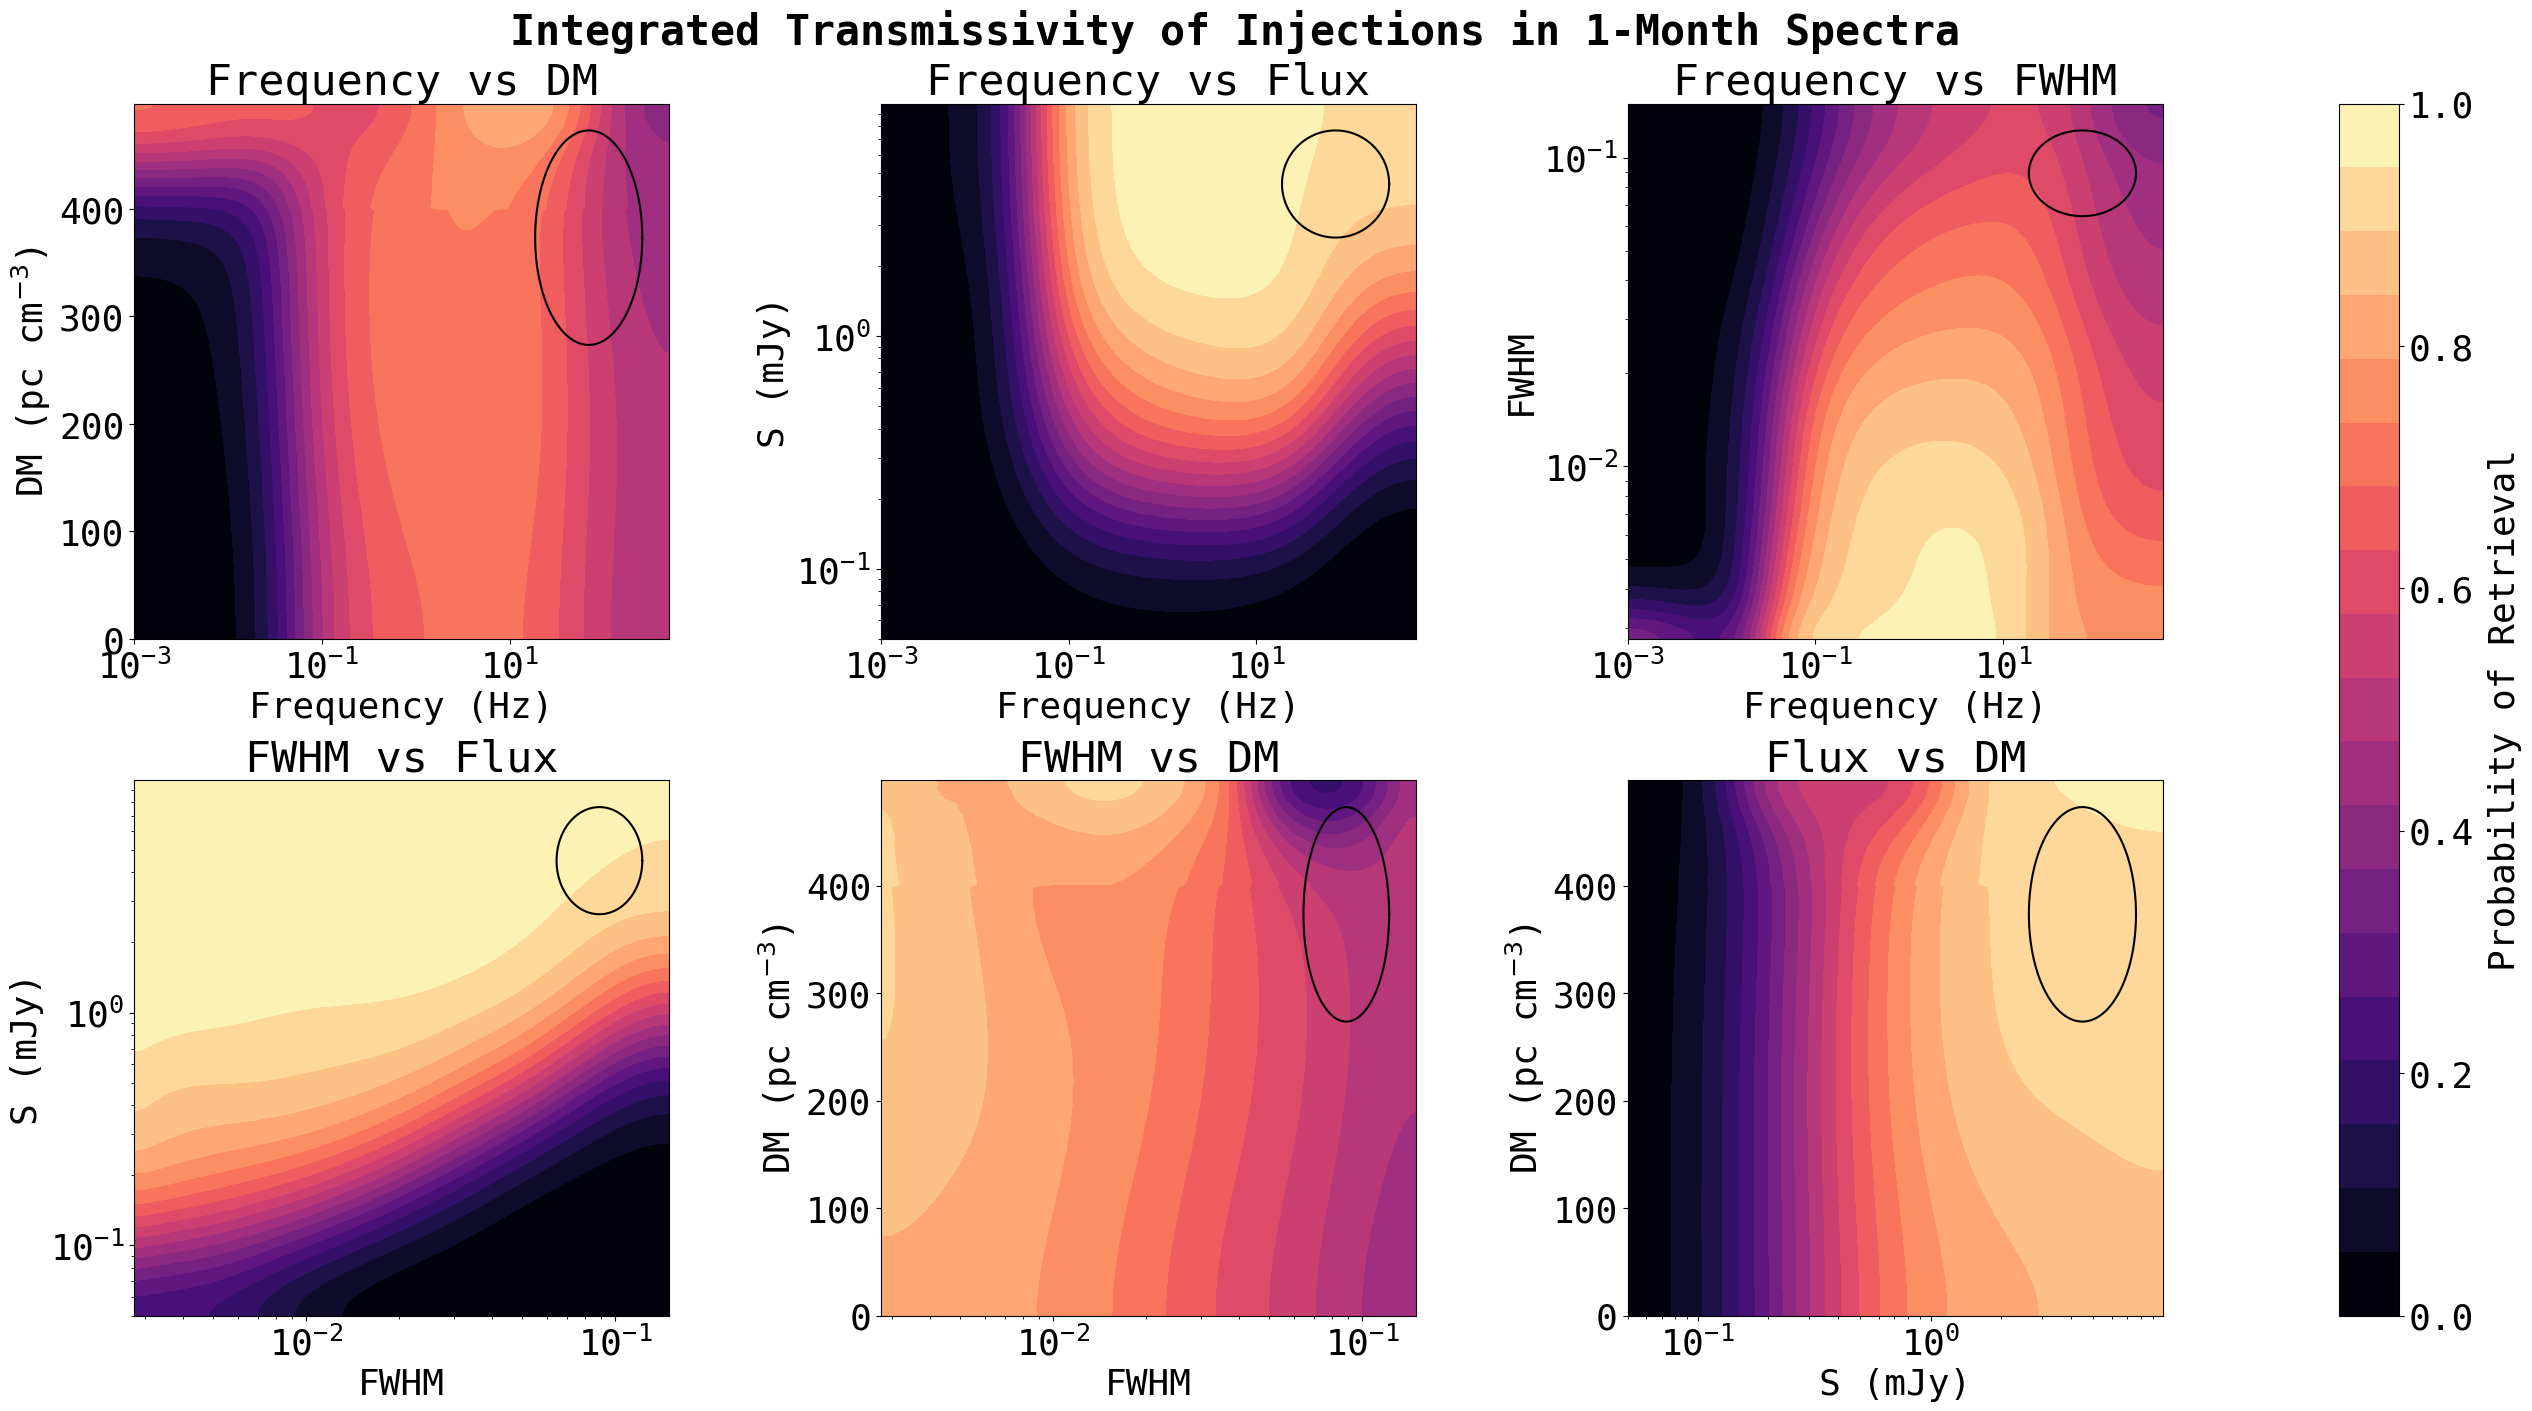

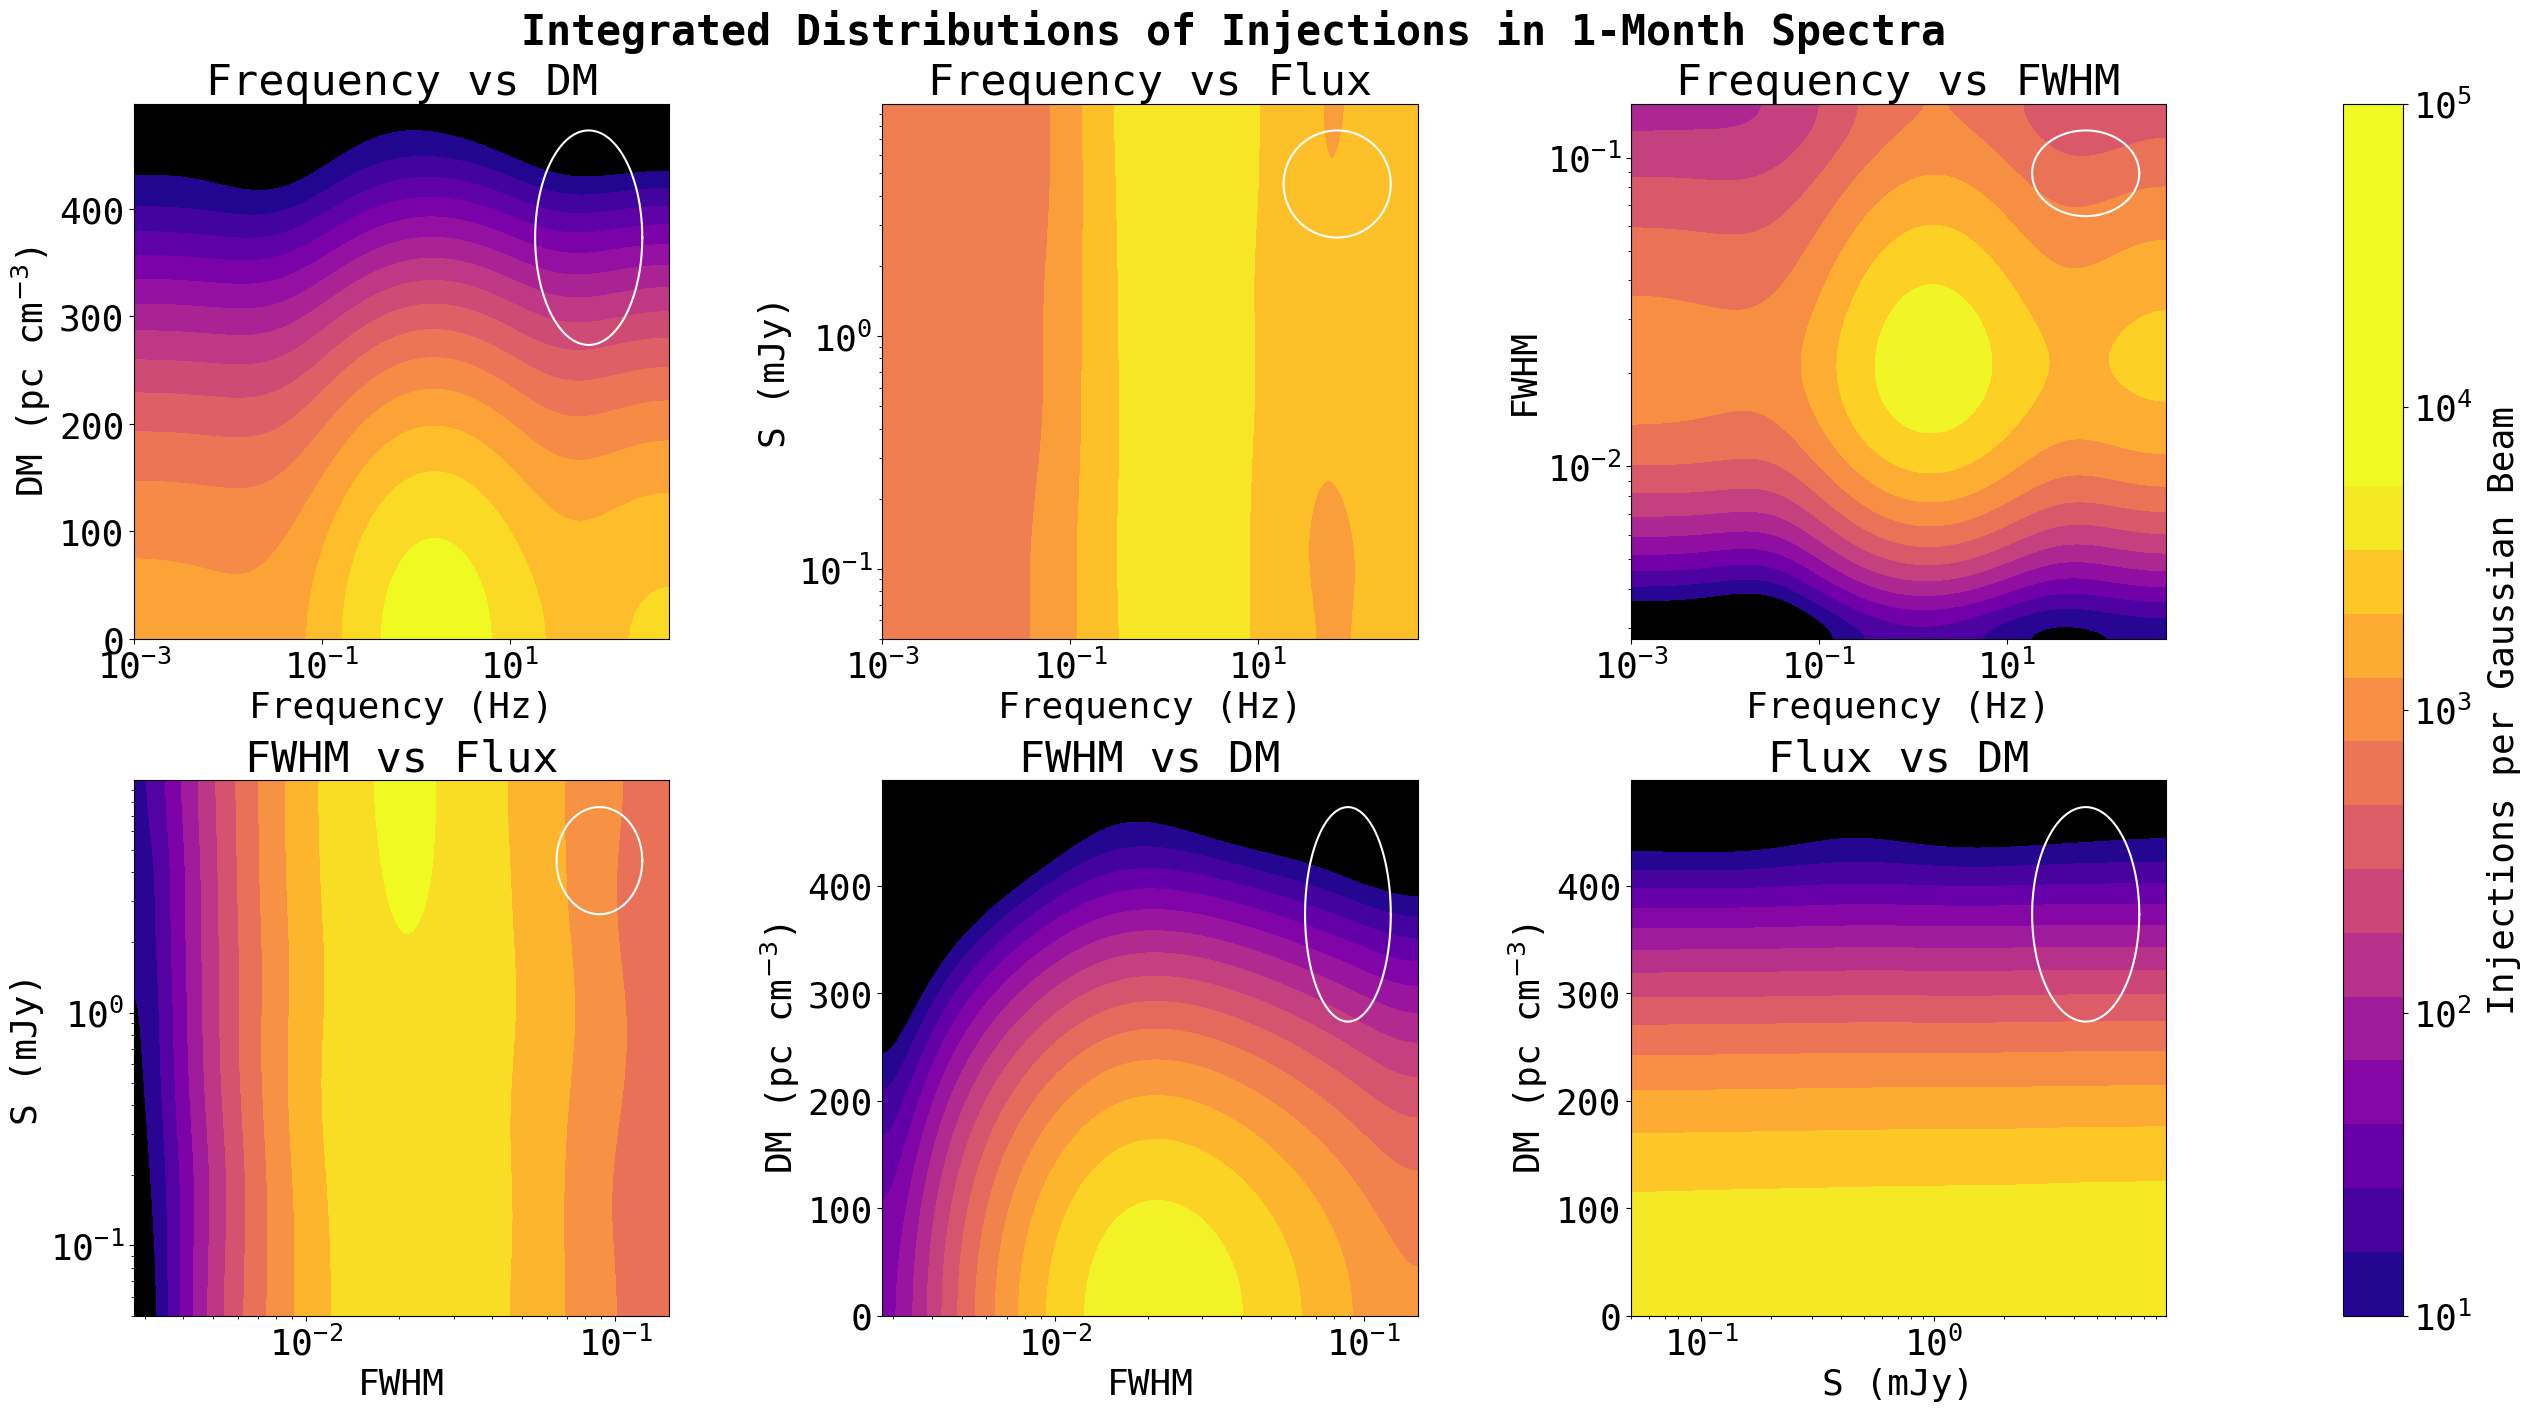

In [604]:
transmissivities_30 = [dm_f_ret_p_smooth_30,  s_f_ret_p_smooth_30, fwhm_f_ret_p_smooth_30,
             s_fwhm_ret_p_smooth_30, dm_fwhm_ret_p_smooth_30, dm_s_ret_p_smooth_30]

au.make_contour_map(transmissivities_30,
                     bins1, bins2, 
                     dev1, dev2, 
                     'Integrated Transmissivity of Injections in 1-Month Spectra',
                     ellipse_colors = ['k', 'k', 'k', 'k', 'k', 'k']
                     )

injections_30 = [dm_f_inj_smooth_30, 
                s_f_inj_smooth_30,
                fwhm_f_inj_smooth_30,
                s_fwhm_inj_smooth_30, 
                dm_fwhm_inj_smooth_30, 
                dm_s_inj_smooth_30]

au.make_contour_map(injections_30,
                     bins1, bins2, 
                     dev1, dev2, 
                     'Integrated Distributions of Injections in 1-Month Spectra',
                     cmap = 'plasma',
                     cmap_log = True,
                     colorbar_name = 'Injections per Gaussian Beam'
                     )

In [605]:
S_mask = data_stack[:, 6] < 0.1
retrieved_mask = data_stack[:, -1] > 0
data_stack_low_flux = data_stack[S_mask]
data_stack_low_flux_retrieved = data_stack[S_mask & retrieved_mask]
100*len(data_stack_low_flux_retrieved) / len(data_stack_low_flux)

0.31429352282044276

In [606]:
sigma_mask = data_stack[:, 8] > 6.

dm_f_inj_smooth_30, _, dm_f_ret_p_smooth_30 = au.get_sensitivity(
    data_stack[sigma_mask & Sglob_mask_stack],
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
)

dm_s_inj_smooth_30, _, dm_s_ret_p_smooth_30 = au.get_sensitivity(
    data_stack[sigma_mask & fglob_mask_stack],
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
)

s_f_inj_smooth_30, _, s_f_ret_p_smooth_30 = au.get_sensitivity(
    data_stack[sigma_mask & DMglob_mask_stack],
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
)

s_fwhm_inj_smooth_30, _, s_fwhm_ret_p_smooth_30 = au.get_sensitivity(
    data_stack[sigma_mask & fglob_mask_stack & DMglob_mask_stack],
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
)

dm_fwhm_inj_smooth_30, _, dm_fwhm_ret_p_smooth_30 = au.get_sensitivity(
    data_stack[sigma_mask & fglob_mask_stack & Sglob_mask_stack],
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
)

fwhm_f_inj_smooth_30, _, fwhm_f_ret_p_smooth_30 = au.get_sensitivity(
    data_stack[sigma_mask & DMglob_mask_stack & Sglob_mask_stack],
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d'
)

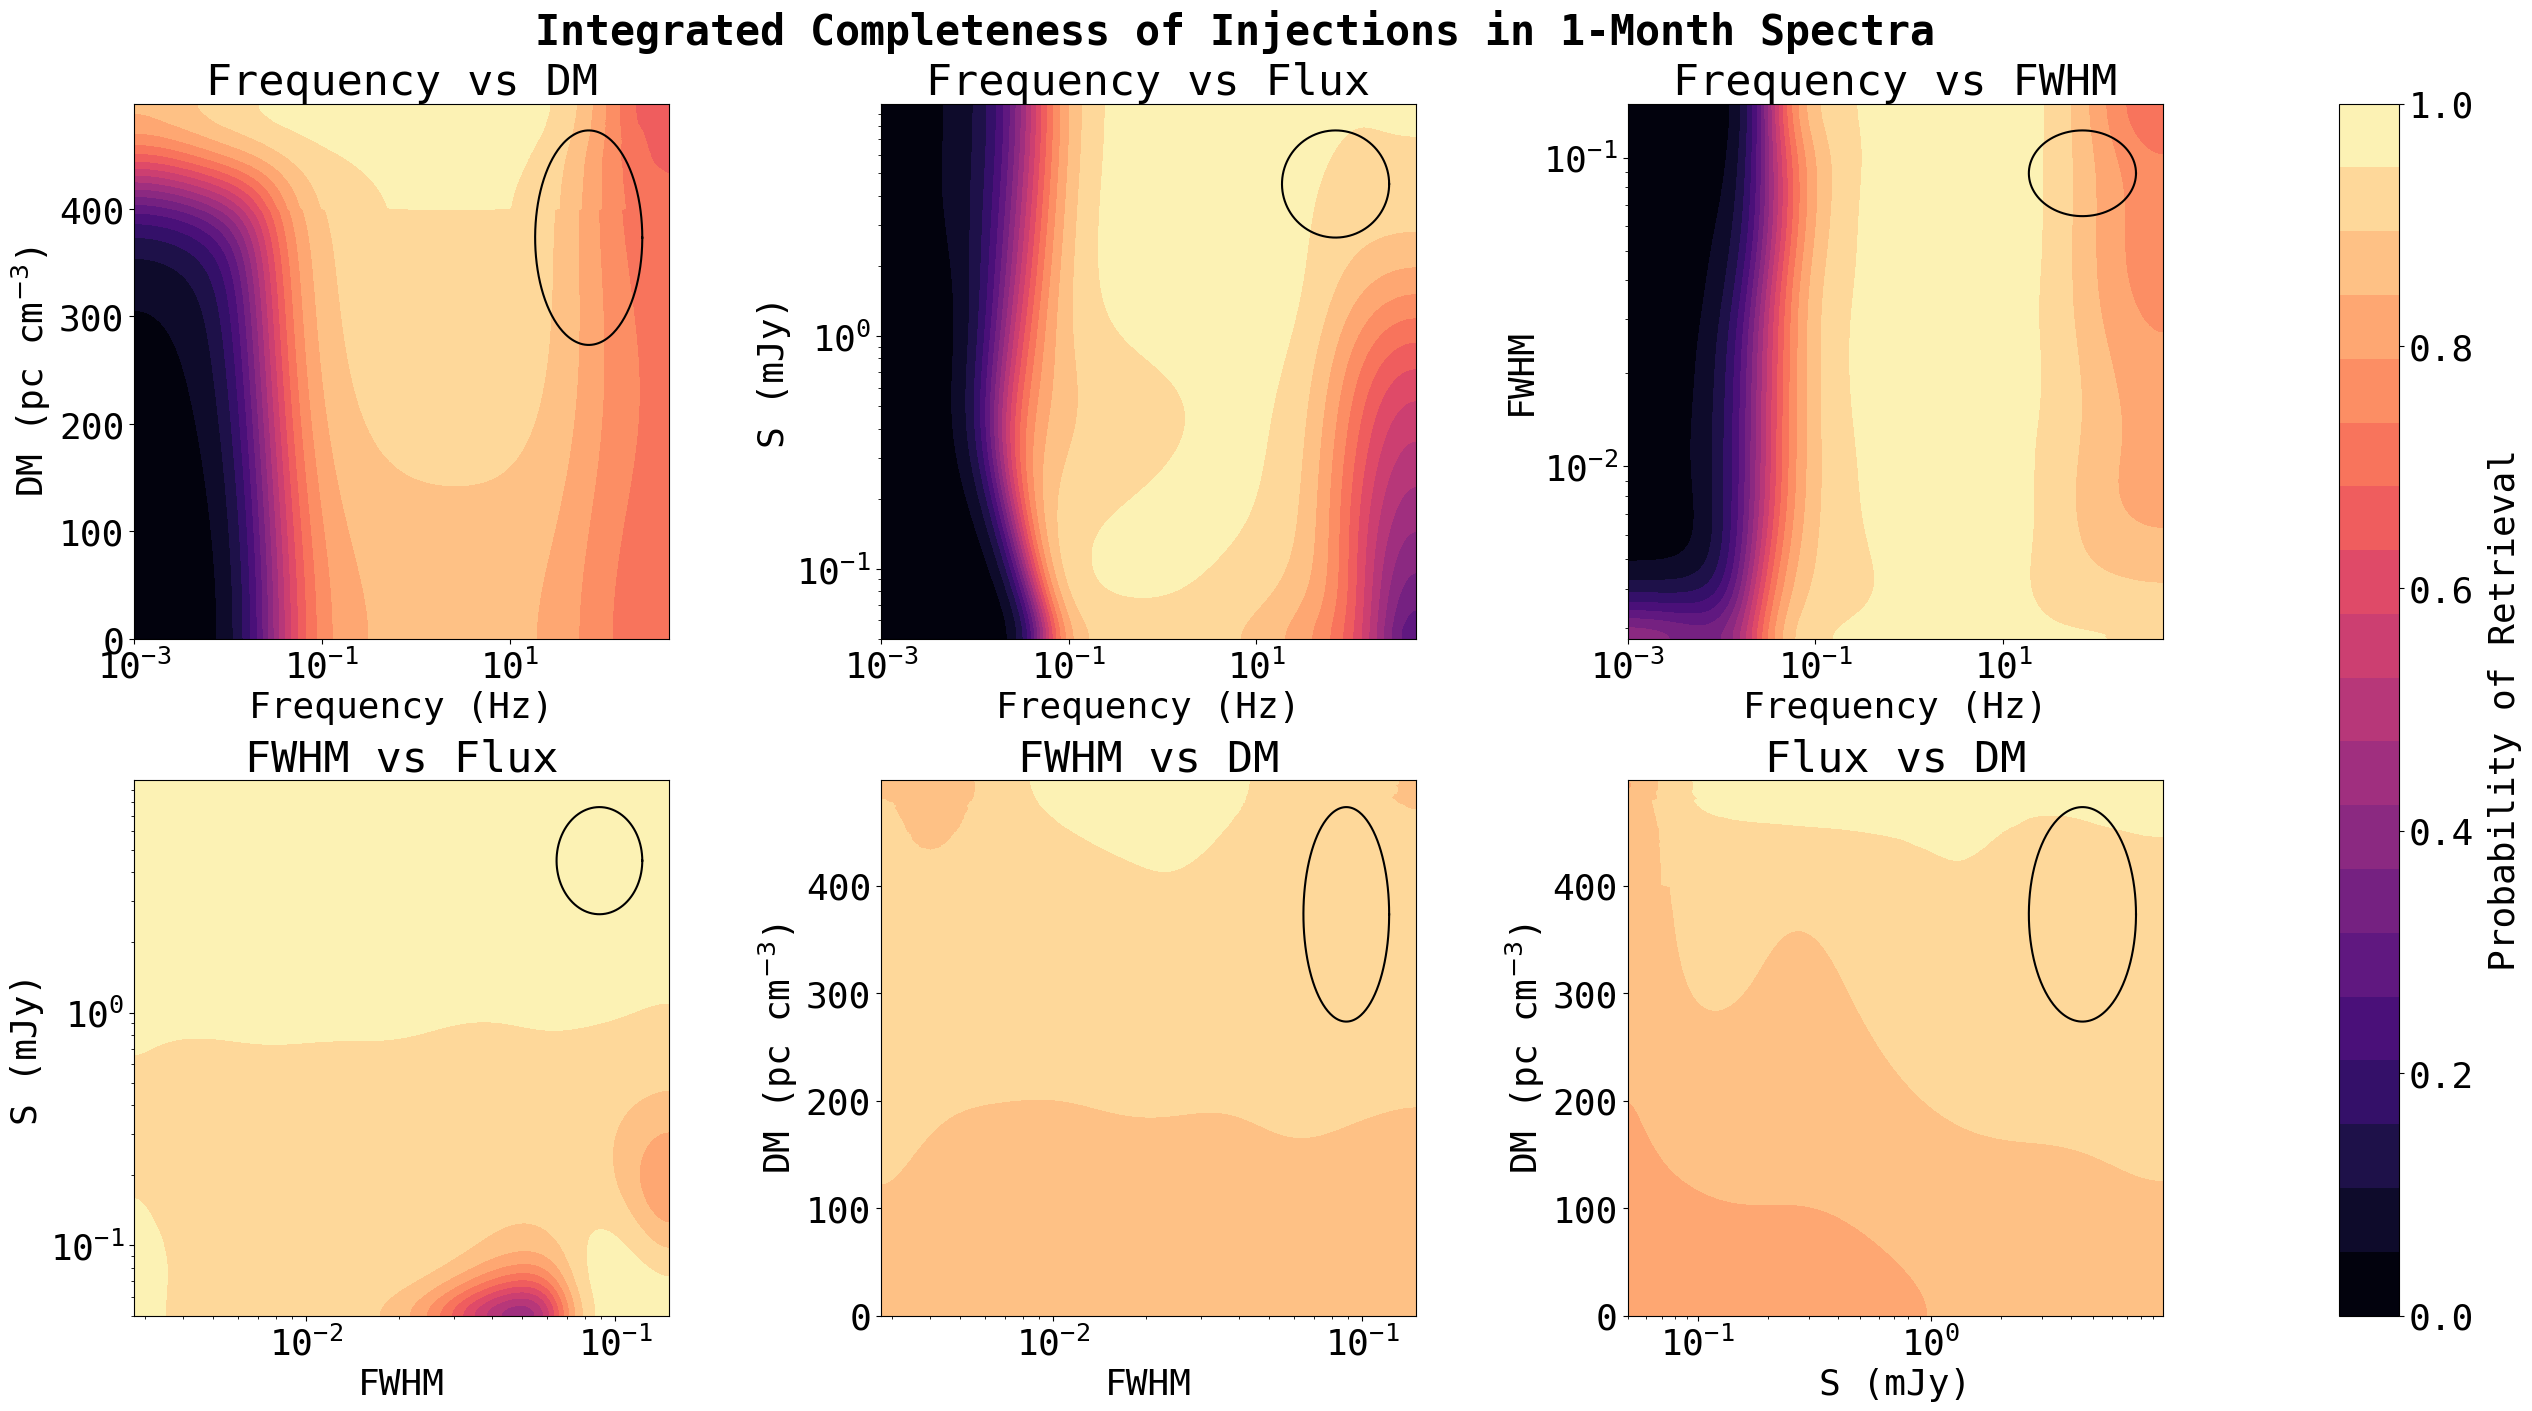

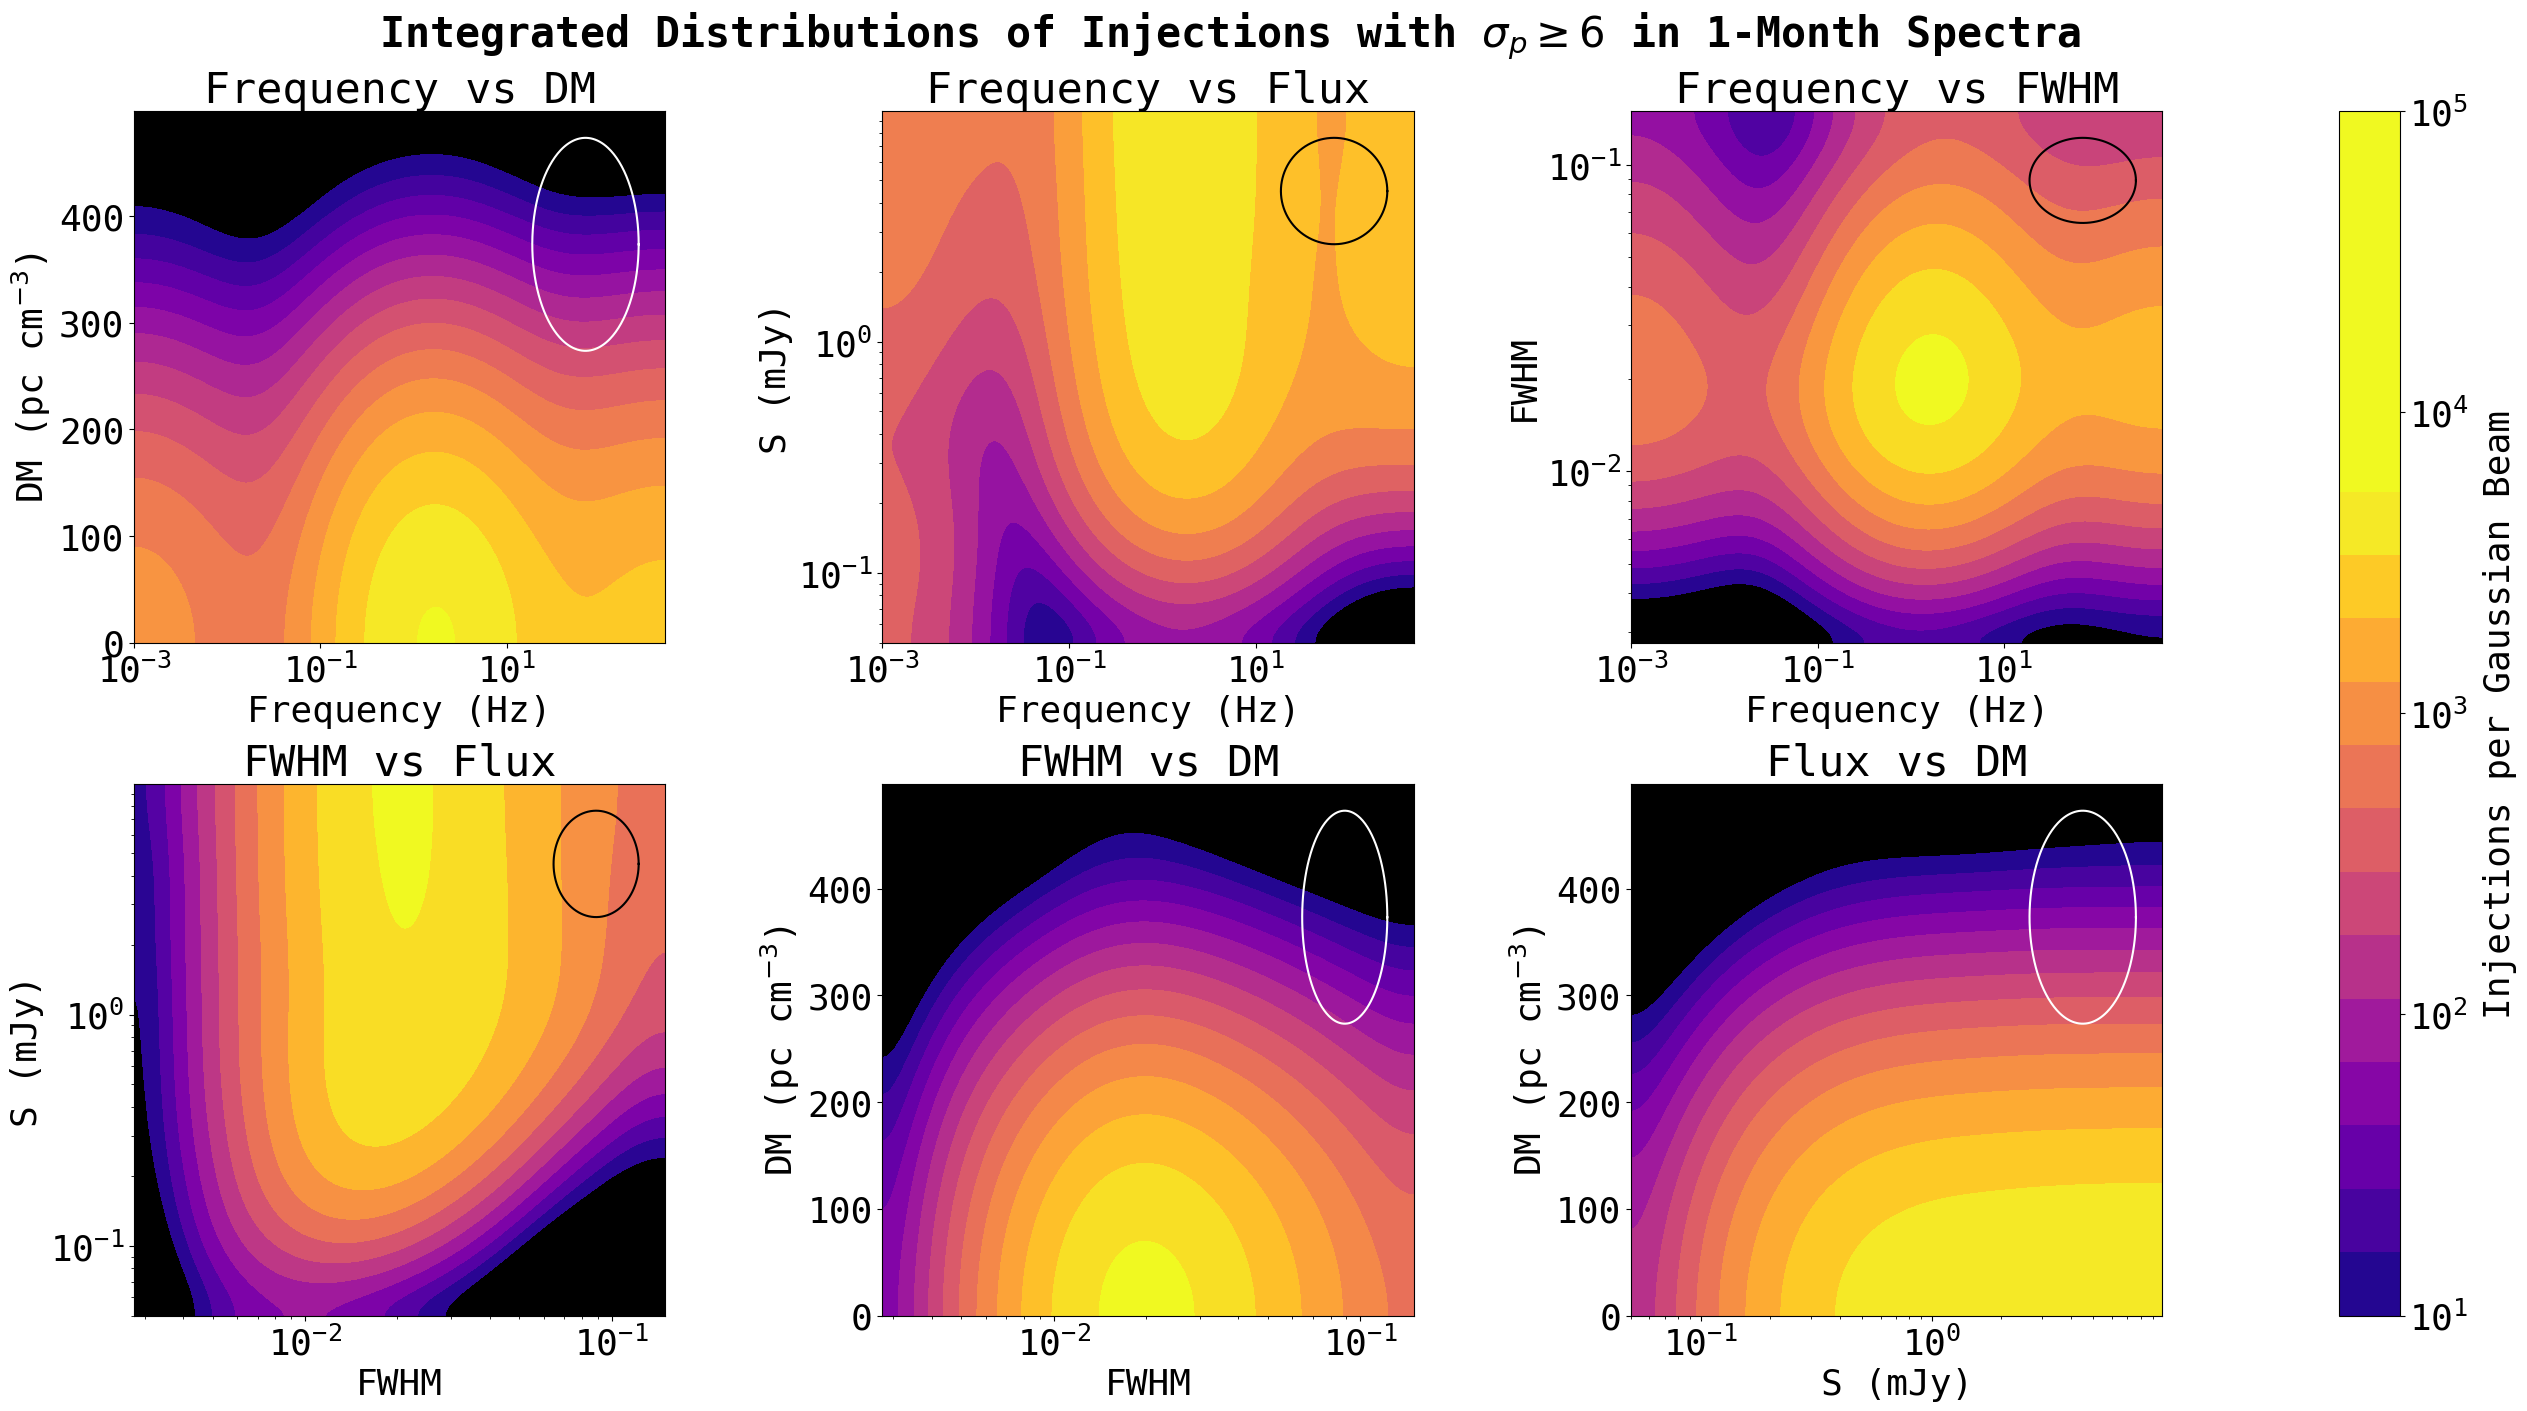

In [607]:
completenesses_30 = [dm_f_ret_p_smooth_30, s_f_ret_p_smooth_30, fwhm_f_ret_p_smooth_30,
             s_fwhm_ret_p_smooth_30, dm_fwhm_ret_p_smooth_30, dm_s_ret_p_smooth_30]

au.make_contour_map(completenesses_30,
                     bins1, bins2, 
                     dev1, dev2, 
                     'Integrated Completeness of Injections in 1-Month Spectra',
                     ellipse_colors = ['k', 'k', 'k', 'k', 'k', 'k']
                     )

injections_30 = [dm_f_inj_smooth_30, 
                s_f_inj_smooth_30,
                fwhm_f_inj_smooth_30,
                s_fwhm_inj_smooth_30, 
                dm_fwhm_inj_smooth_30, 
                dm_s_inj_smooth_30
]

au.make_contour_map(injections_30,
                     bins1, bins2, 
                     dev1, dev2, 
                     r'Integrated Distributions of Injections with $\sigma_p \geq 6$ in 1-Month Spectra',
                     cmap = 'plasma',
                     cmap_log = True,
                     colorbar_name = 'Injections per Gaussian Beam',
                     ellipse_colors = ['w', 'k', 'k', 'k', 'w', 'w']
                     )

Difference between the two...

In [608]:
dm_f_diff = dm_f_ret_p_30 - dm_f_ret_p_1
dm_s_diff = dm_s_ret_p_30 - dm_s_ret_p_1
s_f_diff = s_f_ret_p_30 - s_f_ret_p_1
s_fwhm_diff = s_fwhm_ret_p_30 - s_fwhm_ret_p_1
dm_fwhm_diff = dm_fwhm_ret_p_30 - dm_fwhm_ret_p_1
fwhm_f_diff = fwhm_f_ret_p_30 - fwhm_f_ret_p_1

dm_f_diff_smooth = gaussian_filter(dm_f_diff, (DM_dev, f_dev))
dm_s_diff_smooth = gaussian_filter(dm_s_diff, (DM_dev, S_dev))
s_f_diff_smooth = gaussian_filter(s_f_diff, (S_dev, f_dev))
s_fwhm_diff_smooth = gaussian_filter(s_fwhm_diff, (S_dev, FWHM_dev))
dm_fwhm_diff_smooth = gaussian_filter(dm_fwhm_diff, (DM_dev, FWHM_dev))
fwhm_f_diff_smooth = gaussian_filter(fwhm_f_diff, (FWHM_dev, f_dev))

In [614]:
importlib.reload(au)

<module 'scripts.analysis_utils' from '/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py'>

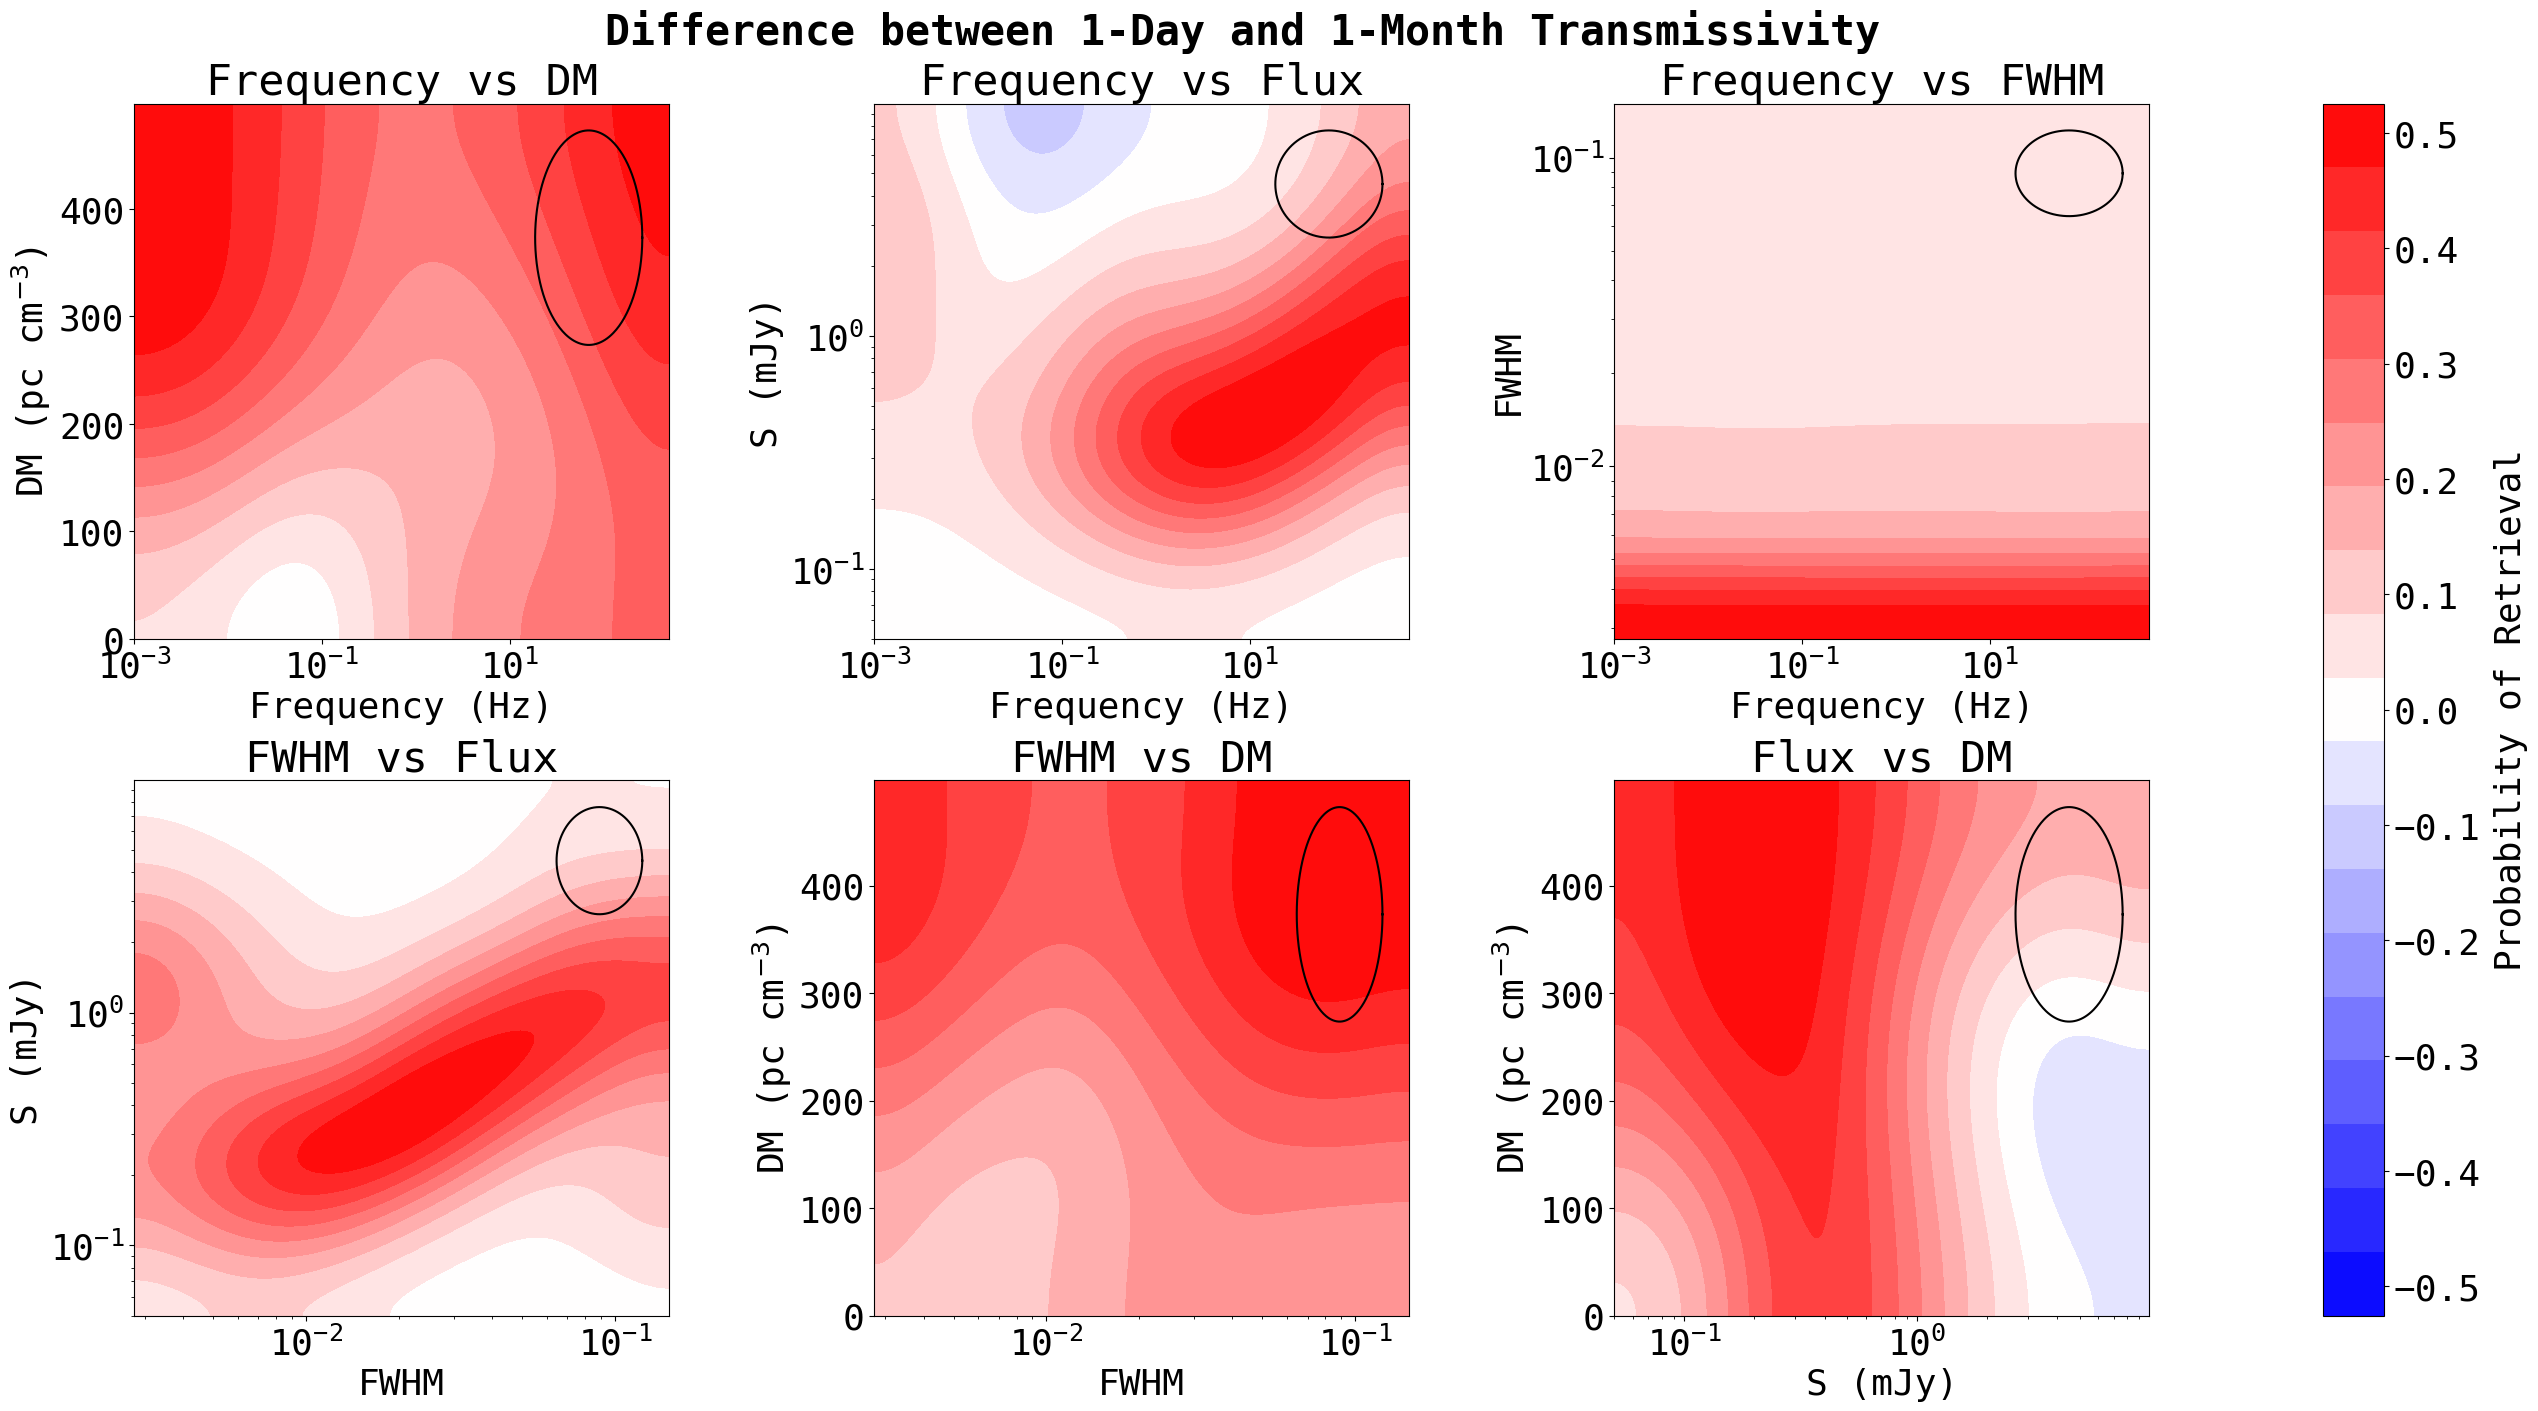

In [615]:
diffs = [dm_f_diff_smooth, s_f_diff_smooth, fwhm_f_diff_smooth,
             s_fwhm_diff_smooth, dm_fwhm_diff_smooth, dm_s_diff_smooth]

au.make_contour_map(diffs,
                     bins1, bins2, 
                     dev1, dev2, 
                     'Difference between 1-Day and 1-Month Transmissivity',
                     ellipse_colors = ['k', 'k', 'k', 'k', 'k', 'k'],
                     cmap_diverging = True,
                     cmap = 'bwr',
                     )

In [611]:
low_freq_mask = data_1[:, f_idx] < 0.05
low_flux_mask = data_1[:, S_idx] < 0.1
hi_flux_mask = data_1[:, S_idx] > 1
retrieved_mask = data_1[:, -1] > 0.
hi_DM_mask = data_1[:, DM_idx] > 400
len(data_1[hi_DM_mask & retrieved_mask])

326